# IEEE-CIS Fraud Detection — Full Pipeline (v3, Improved)
## Phase 1: Data Preparation  |  Phase 2: Generative Modeling  |  Phase 2.5: Synthetic Validation

**Dataset**: IEEE-CIS Fraud Detection (Kaggle Competition)
**Target**: `isFraud` (binary)

This is a full rewrite of the v2 pipeline following the improved architecture:

```
IEEE-CIS Dataset
      │
      ▼
Phase 1: Data Preparation  (modular memory opt, tiered missing-value strategy,
                             tiered categorical encoding, classifier/generator
                             feature split)
      │
      ▼
Phase 2: Generative Modeling  (5 generators: β-CVAE, CTGAN, TVAE, Gaussian
                                Copula, CopulaGAN — feature engineering happens
                                AFTER generation, on top-80 selected features)
      │
      ▼
Phase 2.5: Synthetic Validation  (KS, Wasserstein, JS-divergence, covariance &
                                   correlation preservation, Classifier
                                   Two-Sample Test, PCA/UMAP/t-SNE, diversity,
                                   composite quality score, 5-detector ensemble
                                   filtering, adaptive augmentation-ratio search)
      │
      ▼
Phase 3 / 3.5 / 4  →  see companion notebooks
```

### What changed vs. the previous version
| Area | v2 | v3 (this notebook) |
|---|---|---|
| Memory optimization | inline downcast | reusable `optimize_memory(df)` used everywhere, incl. after every big feature-add step |
| Missing values | one global rule | tiered: continuous→median, categorical→"missing", >95% missing→drop unless important |
| Categorical encoding | label-encode everything left over | tiered: high-cardinality→target encoding, medium→frequency encoding, low→one-hot |
| Feature selection | 310 features straight into generators | classifier keeps ~310, generator gets top 60–100 (MI + LGBM importance + SHAP + correlation pruning) |
| Feature engineering order | before generation | **after** generation for the generator path (raw fraud → select → normalize → generate → validate → filter → engineer → merge) |
| Generators | β-CVAE + CTGAN/TVAE/Copula (unstructured) | 5 tuned generators: β-CVAE, CTGAN, TVAE, Gaussian Copula, CopulaGAN (optional) |
| Synthetic validation | KS + NNDR only | full Phase 2.5: KS, Wasserstein, JS-div, covariance/correlation distance, C2ST, PCA/UMAP/t-SNE, diversity/coverage/density/novelty, composite quality score |
| Filtering | Isolation Forest + Mahalanobis | 5-detector majority vote: Isolation Forest, LOF, One-Class SVM, Mahalanobis, Robust Covariance |
| Augmentation ratio | fixed 30/50/70% ablation | adaptive grid search over 10/20/30/40/60/80/100% using validation F1 |
| Experiment tracking | none | every experiment logged (config, timing, memory, quality + val/test metrics) to `experiment_log.csv` |

Phase 3 (classifier + Optuna + calibration + ensembling), Phase 3.5 (threshold optimization),
and Phase 4 (SHAP + ablation studies) live in the companion notebooks, since each phase
now saves/loads its own artifacts and is meant to be run as a separate Kaggle session.


## 1. Imports, Configuration & Experiment Tracking

In [1]:

import subprocess, sys, os, warnings, gc, time, json, hashlib
from collections import defaultdict, Counter
from contextlib import contextmanager

# ── Install optional packages ─────────────────────────────────────────────────
for pkg, imp in [('sdv', 'sdv'), ('imbalanced-learn', 'imblearn'),
                  ('umap-learn', 'umap'), ('optuna', 'optuna')]:
    try:
        __import__(imp)
        print(f'[OK] {pkg}')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'[INSTALLED] {pkg}')

import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import mahalanobis
from scipy.stats import ks_2samp, wasserstein_distance, entropy
from scipy.cluster.hierarchy import linkage, leaves_list

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, OneHotEncoder
from sklearn.ensemble import (RandomForestClassifier, IsolationForest,
                               HistGradientBoostingClassifier)
from sklearn.covariance import EllipticEnvelope, MinCovDet
from sklearn.svm import OneClassSVM
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve, f1_score, recall_score,
    roc_curve, precision_score, accuracy_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.neighbors import NearestNeighbors
import joblib

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_OK = True; print('[OK] imbalanced-learn')
except ImportError:
    IMBLEARN_OK = False; print('[WARN] imbalanced-learn not available')

try:
    import xgboost as xgb; XGB_OK = True
    print(f'[OK] XGBoost {xgb.__version__}')
except ImportError:
    XGB_OK = False; print('[WARN] XGBoost not found')

try:
    import lightgbm as lgb; LGB_OK = True
    print(f'[OK] LightGBM {lgb.__version__}')
except ImportError:
    LGB_OK = False; print('[WARN] LightGBM not found')

try:
    from sdv.single_table import (CTGANSynthesizer, TVAESynthesizer,
                                   GaussianCopulaSynthesizer, CopulaGANSynthesizer)
    from sdv.metadata import SingleTableMetadata
    SDV_OK = True; print('[OK] SDV')
except ImportError:
    SDV_OK = False; print('[WARN] SDV not installed')

try:
    import umap
    UMAP_OK = True; print('[OK] umap-learn')
except ImportError:
    UMAP_OK = False; print('[WARN] umap-learn not available (t-SNE/PCA still used)')

import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
try: plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('ggplot')
sns.set_palette('husl'); sns.set_context('notebook', font_scale=1.1)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\n[DEVICE] {DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


# ─────────────────────────────────────────────────────────────────────────────
# Reusable memory optimizer (Phase 1 / Step 2)
# ─────────────────────────────────────────────────────────────────────────────
def optimize_memory(df, verbose=False):
    '''
    Downcast numeric dtypes to the smallest safe type.
    int64 → int32/int16/int8   |   float64 → float32/float16
    Reusable anywhere in the pipeline (post-load, post-feature-engineering, etc).
    '''
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object or str(col_type) == 'category':
            continue
        c_min, c_max = df[col].min(), df[col].max()
        if pd.isnull(c_min) or pd.isnull(c_max):
            continue
        if str(col_type)[:3] == 'int':
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            # float: prefer float32; only drop to float16 if values are within its safe range
            if (c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max
                    and df[col].dropna().apply(float.is_integer if False else (lambda x: True)).all()):
                # float16 has poor precision for continuous fraud amounts — use float32 as the
                # default safe downcast, only going to float16 for clearly low-precision columns.
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f'  Memory: {start_mem:.1f}MB → {end_mem:.1f}MB '
              f'({(1 - end_mem/max(start_mem,1e-9))*100:.1f}% reduction)')
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Experiment tracking (logs every experiment across the whole pipeline)
# ─────────────────────────────────────────────────────────────────────────────
EXPERIMENT_LOG_PATH = 'experiment_log.csv'
_experiment_records = []

def log_experiment(name, phase, config=None, timing_s=None, memory_mb=None,
                    quality_metrics=None, val_metrics=None, test_metrics=None, notes=''):
    '''
    Append one row to the running experiment log and persist to CSV immediately,
    so partial pipeline runs (e.g. a Kaggle timeout) still leave a usable record.
    '''
    rec = {
        'timestamp':  pd.Timestamp.now().isoformat(),
        'phase':      phase,
        'experiment': name,
        'seed':       SEED,
        'config':     json.dumps(config or {}, default=str),
        'timing_s':   round(timing_s, 2) if timing_s is not None else None,
        'memory_mb':  round(memory_mb, 1) if memory_mb is not None else None,
        'quality_metrics': json.dumps(quality_metrics or {}, default=str),
        'val_metrics':     json.dumps(val_metrics or {}, default=str),
        'test_metrics':    json.dumps(test_metrics or {}, default=str),
        'notes': notes,
    }
    _experiment_records.append(rec)
    pd.DataFrame(_experiment_records).to_csv(EXPERIMENT_LOG_PATH, index=False)
    return rec

@contextmanager
def timed(name):
    '''Context manager returning elapsed seconds via a mutable holder.'''
    t0 = time.time()
    holder = {'elapsed': None}
    yield holder
    holder['elapsed'] = time.time() - t0

def current_process_memory_mb():
    '''Best-effort RSS memory in MB (falls back to 0 if psutil unavailable).'''
    try:
        import psutil, os as _os
        return psutil.Process(_os.getpid()).memory_info().rss / 1024**2
    except Exception:
        return 0.0

print('Environment ready ✓')
print('Experiment tracking → experiment_log.csv (written incrementally)')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.0 MB/s eta 0:00:00
[INSTALLED] sdv
[OK] imbalanced-learn
[OK] umap-learn
[OK] optuna
[OK] imbalanced-learn
[OK] XGBoost 3.2.0
[OK] LightGBM 4.6.0
[OK] SDV
[OK] umap-learn

[DEVICE] cuda
  GPU: Tesla T4
  Memory: 15.6 GB
Environment ready ✓
Experiment tracking → experiment_log.csv (written incrementally)


## 2. Data Loading — IEEE-CIS (Merge Transaction + Identity)

In [2]:

t0 = time.time()
DATA_DIR = '/kaggle/input/competitions/ieee-fraud-detection'

train_txn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
train_id  = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
print(f'train_transaction : {train_txn.shape}')
print(f'train_identity    : {train_id.shape}')

df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f'\nMerged shape : {df.shape}')
print(f'Fraud rate   : {df["isFraud"].mean()*100:.2f}%  ({df["isFraud"].sum():,} / {len(df):,})')

# Apply the reusable memory optimizer right after load — this is the first of
# several passes (Step 2 in the improved plan calls for reuse throughout).
mem_before = df.memory_usage(deep=True).sum() / 1024**2
df = optimize_memory(df, verbose=True)

log_experiment('data_load', phase='phase1', config={'data_dir': DATA_DIR},
               timing_s=time.time() - t0, memory_mb=df.memory_usage(deep=True).sum()/1024**2,
               notes=f'merged shape {df.shape}')
df.head(3)


train_transaction : (590540, 394)
train_identity    : (144233, 41)

Merged shape : (590540, 434)
Fraud rate   : 3.50%  (20,663 / 590,540)
  Memory: 2514.0MB → 1603.3MB (36.2% reduction)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis

=== dtype counts ===
float32    399
object      31
int32        2
int8         1
int16        1
Name: count, dtype: int64

Missing values: 115,523,073  (45.1% overall)


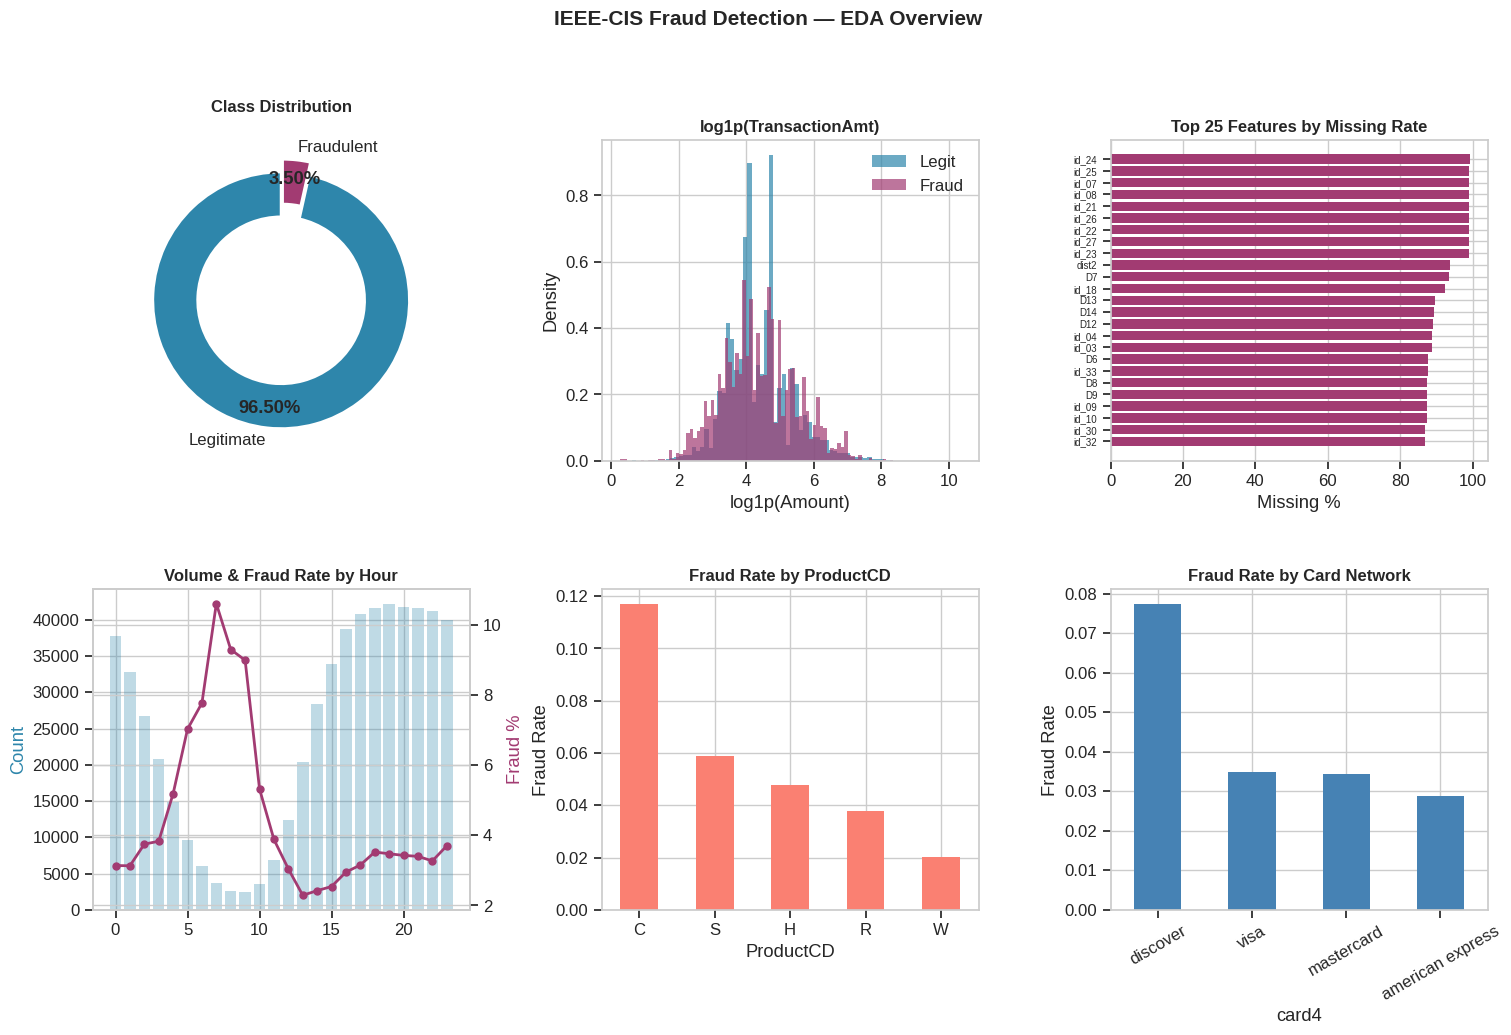

eda_overview.png saved ✓

Top 10 features correlated with isFraud:
isFraud    1.000000
V45        0.281832
V44        0.260376
V86        0.251828
V87        0.251737
V52        0.239469
V51        0.223191
V40        0.212442
V39        0.203097
V38        0.199005


In [3]:

# ── 3.1  Basic Info ───────────────────────────────────────────────────────────
print('=== dtype counts ===')
print(df.dtypes.value_counts())
print(f'\nMissing values: {df.isnull().sum().sum():,}  ({df.isnull().mean().mean()*100:.1f}% overall)')

# ── 3.2  Class Imbalance & Key Distributions ──────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
colors = ['#2E86AB', '#A23B72']
wedges, texts, autotexts = ax1.pie(
    df['isFraud'].value_counts().values, labels=['Legitimate','Fraudulent'],
    colors=colors, autopct='%1.2f%%', startangle=90, pctdistance=0.85,
    explode=(0, 0.1), wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontweight('bold')
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold', pad=20)

ax2 = fig.add_subplot(gs[0, 1])
for label, color, name in [(0,'#2E86AB','Legit'),(1,'#A23B72','Fraud')]:
    ax2.hist(np.log1p(df[df['isFraud']==label]['TransactionAmt']),
             bins=80, alpha=0.7, label=name, color=color, density=True)
ax2.set_title('log1p(TransactionAmt)', fontsize=12, fontweight='bold')
ax2.set_xlabel('log1p(Amount)'); ax2.set_ylabel('Density'); ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
miss = df.isnull().mean().sort_values(ascending=False).head(25)
colors_bar = ['#A23B72' if v>0.8 else '#D64045' if v>0.5 else '#F18F01' for v in miss.values]
ax3.barh(range(len(miss)), miss.values*100, color=colors_bar)
ax3.set_yticks(range(len(miss))); ax3.set_yticklabels(miss.index, fontsize=7)
ax3.invert_yaxis(); ax3.set_xlabel('Missing %')
ax3.set_title('Top 25 Features by Missing Rate', fontsize=12, fontweight='bold')

ax4 = fig.add_subplot(gs[1, 0])
hours = (df['TransactionDT']/3600) % 24
hourly = df.groupby(hours.astype(int))['isFraud'].agg(['mean','count'])
ax4b = ax4.twinx()
ax4.bar(hourly.index, hourly['count'], alpha=0.3, color='#2E86AB')
ax4b.plot(hourly.index, hourly['mean']*100, 'o-', color='#A23B72', lw=2, ms=5)
ax4.set_title('Volume & Fraud Rate by Hour', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', color='#2E86AB'); ax4b.set_ylabel('Fraud %', color='#A23B72')

ax5 = fig.add_subplot(gs[1, 1])
df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False).plot.bar(ax=ax5, color='salmon')
ax5.set_title('Fraud Rate by ProductCD', fontsize=12, fontweight='bold')
ax5.set_ylabel('Fraud Rate'); ax5.tick_params(axis='x', rotation=0)

ax6 = fig.add_subplot(gs[1, 2])
df.groupby('card4')['isFraud'].mean().sort_values(ascending=False).plot.bar(ax=ax6, color='steelblue')
ax6.set_title('Fraud Rate by Card Network', fontsize=12, fontweight='bold')
ax6.set_ylabel('Fraud Rate'); ax6.tick_params(axis='x', rotation=30)

plt.suptitle('IEEE-CIS Fraud Detection — EDA Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('eda_overview.png saved ✓')

num_feats = df.select_dtypes(include=[np.number]).columns
valid_num  = [c for c in num_feats if df[c].isnull().mean() < 0.5]
target_corr = df[valid_num].corrwith(df['isFraud']).sort_values(ascending=False)
print('\nTop 10 features correlated with isFraud:')
print(target_corr.head(10).to_string())


## 4. Preprocessing — Missing Values, Type Handling & Correlated Feature Removal

**Step 3 (tiered missing-value strategy)**, applied instead of one global rule:
- Continuous → median
- Categorical → `"missing"` sentinel category
- Very sparse (>95% missing) → drop, **unless** the column is known to carry fraud signal
  (checked via correlation with `isFraud` before dropping)


In [4]:

t0 = time.time()

# ── 4.1  Tiered handling of ultra-sparse columns (>95% missing) ─────────────
# Instead of a blanket >90% drop, check whether a very-sparse column still
# correlates meaningfully with the target before dropping it.
miss_frac = df.isnull().mean()
very_sparse = miss_frac[miss_frac > 0.95].index.tolist()

KNOWN_IMPORTANT = set()  # columns to always keep even if very sparse (populate if known)
target_corr_check = {}
for col in very_sparse:
    if col == 'isFraud':
        continue
    if df[col].dtype == object:
        # correlation via fraud-rate spread across categories
        try:
            grp = df.groupby(col)['isFraud'].mean()
            spread = grp.max() - grp.min() if len(grp) > 1 else 0
            target_corr_check[col] = spread
        except Exception:
            target_corr_check[col] = 0
    else:
        target_corr_check[col] = abs(df[[col, 'isFraud']].corr().iloc[0, 1]) if df[col].notna().sum() > 10 else 0

IMPORTANCE_KEEP_THRESHOLD = 0.05
keep_sparse = [c for c in very_sparse
               if c in KNOWN_IMPORTANT or target_corr_check.get(c, 0) > IMPORTANCE_KEEP_THRESHOLD]
drop_cols = [c for c in very_sparse if c not in keep_sparse]

print(f'>95% missing columns: {len(very_sparse)}')
print(f'  Kept (signal found): {len(keep_sparse)}  {keep_sparse[:10]}')
print(f'  Dropped: {len(drop_cols)}')
df.drop(columns=drop_cols, inplace=True)

# ── 4.2  Separate target ──────────────────────────────────────────────────────
y  = df['isFraud'].astype(int)
df = df.drop(columns=['isFraud', 'TransactionID'])

# ── 4.3  Identify column types ────────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()
print(f'\nCategorical: {len(cat_cols)}  |  Numerical: {len(num_cols)}')

# ── 4.4  Tiered missing-value fill ────────────────────────────────────────────
# Continuous → median   |   Categorical → "missing" sentinel
for col in cat_cols:
    df[col] = df[col].fillna('missing')
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
print(f'Remaining NaN: {df.isnull().sum().sum()}')

# ── 4.5  Remove near-zero variance features ───────────────────────────────────
num_only = df.select_dtypes(include=[np.number]).columns.tolist()
sel = VarianceThreshold(threshold=0.01)
sel.fit(df[num_only].fillna(0))
low_var = [c for c, keep in zip(num_only, sel.get_support()) if not keep]
print(f'Removing {len(low_var)} near-zero variance features')
df.drop(columns=low_var, inplace=True)

# ── 4.6  Remove highly correlated features (r > 0.95) ─────────────────────────
num_final = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_final].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Removing {len(to_drop_corr)} highly correlated features (r > 0.95)')
df.drop(columns=to_drop_corr, inplace=True)

# ── 4.7  Memory optimise (reusable function, 2nd pass) ────────────────────────
df = optimize_memory(df, verbose=True)

# ── 4.8  Missing indicators for high-missing columns ─────────────────────────
high_miss = miss_frac[miss_frac > 0.3].index.tolist()
added = 0
for col in high_miss[:10]:
    if col in df.columns:
        df[f'{col}_was_missing'] = df[col].isnull().astype(np.int8)
        added += 1
print(f'Added {added} missing indicator features')

print(f'\nFeature count after cleaning: {df.shape[1]}')
print('\n=== DATA VALIDATION ===')
print(f'✓ Shape: {df.shape}')
print(f'✓ Zero NaN: {df.isnull().sum().sum() == 0}')
print(f'✓ Correlated features removed')
print(f'✓ Class imbalance ratio: {(1-y.mean())/y.mean():.1f}:1')

log_experiment('preprocessing', phase='phase1',
               config={'sparse_dropped': len(drop_cols), 'sparse_kept': len(keep_sparse),
                        'low_var_dropped': len(low_var), 'corr_dropped': len(to_drop_corr)},
               timing_s=time.time()-t0, memory_mb=df.memory_usage(deep=True).sum()/1024**2,
               notes=f'shape after cleaning {df.shape}')


>95% missing columns: 9
  Kept (signal found): 7  ['id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_26', 'id_27']
  Dropped: 2

Categorical: 31  |  Numerical: 399
Remaining NaN: 0
Removing 25 near-zero variance features
Removing 108 highly correlated features (r > 0.95)
  Memory: 1556.0MB → 1556.0MB (0.0% reduction)
Added 10 missing indicator features

Feature count after cleaning: 307

=== DATA VALIDATION ===
✓ Shape: (590540, 307)
✓ Zero NaN: True
✓ Correlated features removed
✓ Class imbalance ratio: 27.6:1


{'timestamp': '2026-07-09T09:22:37.060388',
 'phase': 'phase1',
 'experiment': 'preprocessing',
 'seed': 42,
 'config': '{"sparse_dropped": 2, "sparse_kept": 7, "low_var_dropped": 25, "corr_dropped": 108}',
 'timing_s': 250.87,
 'memory_mb': np.float64(1561.7),
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': 'shape after cleaning (590540, 307)'}

## 5. Feature Engineering (Modular)

**Step 5 improvement**: features are organized into clearly separated modules
(Time / Transaction / Identity / Card / Aggregations / Interactions) instead of one
monolithic cell, and the polynomial interaction step is restricted to a handful of
selected important variables instead of dozens of manual combinations.


In [5]:

t0 = time.time()

# ─────────────────────────────────────────────────────────────────────────────
# MODULE: Time features
# ─────────────────────────────────────────────────────────────────────────────
def add_time_features(df):
    if 'TransactionDT' in df.columns:
        df['DT_hour_of_day'] = (df['TransactionDT'] / 3600) % 24
        df['DT_day_of_week'] = (df['TransactionDT'] / (3600*24)) % 7
        df['DT_week']        = (df['TransactionDT'] / (3600*24*7)).astype(int)
        df['DT_month']       = (df['TransactionDT'] / (3600*24*30)).astype(int)
        df['DT_is_night']    = ((df['DT_hour_of_day'] >= 22) | (df['DT_hour_of_day'] <= 5)).astype(int)
        df['DT_is_weekend']  = (df['DT_day_of_week'] >= 5).astype(int)
        print('  [time] hour/day/week/month/weekend features added ✓')
    return df

# ─────────────────────────────────────────────────────────────────────────────
# MODULE: Transaction amount features
# ─────────────────────────────────────────────────────────────────────────────
def add_transaction_features(df):
    if 'TransactionAmt' in df.columns:
        df['TransactionAmt_log']      = np.log1p(df['TransactionAmt'])
        df['TransactionAmt_decimal']  = df['TransactionAmt'] - df['TransactionAmt'].astype(int)
        df['TransactionAmt_is_round'] = (df['TransactionAmt_decimal'] == 0).astype(int)
        print('  [transaction] log amount / decimal / round-amount features added ✓')
    return df

# ─────────────────────────────────────────────────────────────────────────────
# MODULE: Card / customer / merchant rolling aggregations (z-scores, mean, std)
# ─────────────────────────────────────────────────────────────────────────────
def add_card_aggregation_features(df):
    if 'card1' in df.columns and 'TransactionAmt' in df.columns:
        for grp in ['card1', 'card2']:
            if grp in df.columns:
                grp_key = df[grp].astype(np.float32)
                mu  = df.groupby(grp_key)['TransactionAmt'].transform('mean')
                sig = df.groupby(grp_key)['TransactionAmt'].transform('std').fillna(0)
                df[f'{grp}_amt_mean']   = mu
                df[f'{grp}_amt_std']    = sig
                df[f'{grp}_amt_zscore'] = (df['TransactionAmt'] - mu) / (sig + 1e-9)
        print('  [card] customer/card rolling mean/std/z-score features added ✓')
    return df

def add_merchant_aggregation_features(df):
    # ProductCD acts as a merchant/product-category proxy in IEEE-CIS
    if 'ProductCD' in df.columns and 'TransactionAmt' in df.columns:
        mu  = df.groupby(df['ProductCD'])['TransactionAmt'].transform('mean')
        sig = df.groupby(df['ProductCD'])['TransactionAmt'].transform('std').fillna(0)
        df['ProductCD_amt_mean']   = mu
        df['ProductCD_amt_std']    = sig
        df['ProductCD_amt_zscore'] = (df['TransactionAmt'] - mu) / (sig + 1e-9)
        print('  [merchant] ProductCD rolling mean/std/z-score features added ✓')
    return df

def add_address_aggregation_features(df):
    if 'addr1' in df.columns and 'TransactionAmt' in df.columns:
        mu = df.groupby(df['addr1'])['TransactionAmt'].transform('mean')
        df['addr1_amt_mean'] = mu
        df['addr1_amt_zscore'] = (df['TransactionAmt'] - mu) / (df['TransactionAmt'].std() + 1e-9)
        print('  [address] addr1 rolling mean/z-score features added ✓')
    return df

# ─────────────────────────────────────────────────────────────────────────────
# MODULE: Identity features (browser/device/OS/email domain/country flags)
# ─────────────────────────────────────────────────────────────────────────────
def add_identity_features(df):
    if 'id_30' in df.columns:  # OS
        df['OS_name'] = df['id_30'].astype(str).str.split(' ').str[0]
    if 'id_31' in df.columns:  # browser
        df['browser_name'] = df['id_31'].astype(str).str.extract(r'([a-zA-Z]+)')[0]
    if 'DeviceType' in df.columns:
        df['is_mobile'] = (df['DeviceType'] == 'mobile').astype(int)
    for ecol in ['P_emaildomain', 'R_emaildomain']:
        if ecol in df.columns:
            df[f'{ecol}_suffix'] = df[ecol].astype(str).str.split('.').str[-1]
    print('  [identity] browser/OS/device/email-suffix features added ✓')
    return df

# ─────────────────────────────────────────────────────────────────────────────
# MODULE: M-column flag sums (identity-match flags)
# ─────────────────────────────────────────────────────────────────────────────
def add_m_flag_features(df):
    m_cols = [c for c in df.columns if c.startswith('M') and c[1:].isdigit()]
    if m_cols:
        m_enc = df[m_cols].replace({'T':1,'F':0,'missing':-1})
        df['M_sum']        = (m_enc == 1).sum(axis=1)
        df['M_miss_count'] = (m_enc == -1).sum(axis=1)
        print(f'  [M-flags] {len(m_cols)} columns summarized ✓')
    return df

# ─────────────────────────────────────────────────────────────────────────────
# MODULE: Selected polynomial interactions (only top important variables,
# NOT dozens of manual pairwise combos as before)
# ─────────────────────────────────────────────────────────────────────────────
def add_selected_interactions(df, important_pairs):
    '''important_pairs: list of (colA, colB) tuples to multiply/divide.'''
    added = 0
    for a, b in important_pairs:
        if a in df.columns and b in df.columns:
            df[f'{a}_x_{b}'] = df[a].astype(np.float32) * df[b].astype(np.float32)
            added += 1
    print(f'  [interactions] {added} selected polynomial interaction features added ✓')
    return df

# ── Run the pipeline modules in order ─────────────────────────────────────────
print('Running modular feature engineering …')
df = add_time_features(df)
df = add_transaction_features(df)
df = add_card_aggregation_features(df)
df = add_merchant_aggregation_features(df)
df = add_address_aggregation_features(df)
df = add_identity_features(df)
df = add_m_flag_features(df)

# Selected interactions — pick a small, defensible set of high-signal pairs
# instead of an exhaustive polynomial expansion.
candidate_pairs = [
    ('TransactionAmt_log', 'card1_amt_zscore'),
    ('TransactionAmt_log', 'DT_is_night'),
    ('card1_amt_zscore', 'card2_amt_zscore'),
]
df = add_selected_interactions(df, candidate_pairs)

df = optimize_memory(df, verbose=True)  # 3rd reuse of the memory optimizer

log_experiment('feature_engineering_modular', phase='phase1',
               config={'interaction_pairs': len(candidate_pairs)},
               timing_s=time.time()-t0, memory_mb=df.memory_usage(deep=True).sum()/1024**2,
               notes=f'shape after modular FE {df.shape}')
print(f'\nShape after modular feature engineering: {df.shape}')


Running modular feature engineering …
  [time] hour/day/week/month/weekend features added ✓
  [transaction] log amount / decimal / round-amount features added ✓
  [card] customer/card rolling mean/std/z-score features added ✓
  [merchant] ProductCD rolling mean/std/z-score features added ✓
  [address] addr1 rolling mean/z-score features added ✓
  [identity] browser/OS/device/email-suffix features added ✓
  [M-flags] 9 columns summarized ✓
  [interactions] 3 selected polynomial interaction features added ✓
  Memory: 1768.4MB → 1730.1MB (2.2% reduction)

Shape after modular feature engineering: (590540, 337)


## 6. Categorical Encoding — Tiered by Cardinality

**Step 4 improvement**: instead of target-encoding everything, features are split by
cardinality and encoded with the technique best suited to each tier:
- **High cardinality** (>50 uniques, e.g. V-columns, card fields, email domains) → k-fold
  target-mean encoding (prevents leakage via cross-fitting)
- **Medium cardinality** (11–50 uniques) → frequency encoding
- **Low cardinality** (≤10 uniques, e.g. ProductCD, card4/card6, M-flags) → one-hot encoding

This avoids the overfitting risk of target-encoding low-cardinality columns (where a
handful of categories can otherwise memorize the fold-level target).


In [6]:

t0 = time.time()
global_mean = y.mean()

def kfold_target_encode(df_in, col, target, n_splits=5, smoothing=10):
    '''
    Encode col → mean fraud rate using k-fold cross-fitting.
    smoothing: blends per-category mean toward global mean for rare categories.
    '''
    encoded = pd.Series(np.nan, index=df_in.index, dtype=np.float32)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    col_series = df_in[col].astype(str)
    target_arr = target.values

    for fold, (train_idx, val_idx) in enumerate(skf.split(df_in, target)):
        tmp = pd.DataFrame({'col': col_series.iloc[train_idx], 'tgt': target_arr[train_idx]})
        stats_fold = tmp.groupby('col')['tgt'].agg(['mean', 'count'])
        smooth_mean = (stats_fold['count'] * stats_fold['mean'] + smoothing * global_mean) / (stats_fold['count'] + smoothing)
        val_col = col_series.iloc[val_idx]
        encoded.iloc[val_idx] = val_col.map(smooth_mean).fillna(global_mean).values

    return encoded.fillna(global_mean)

def frequency_encode(df_in, col):
    '''Medium-cardinality → replace category with its normalized frequency.'''
    freq = df_in[col].astype(str).value_counts(normalize=True)
    return df_in[col].astype(str).map(freq).fillna(0).astype(np.float32)

# ── 6.1 Split all non-numeric / categorical-like columns by cardinality ──────
cat_like_cols = df.select_dtypes(include='object').columns.tolist()
# Also treat numeric-but-categorical anonymized columns (V*, id_*) as candidates
# for target/frequency encoding if they look categorical (low unique count relative
# to row count is handled per-column below via nunique thresholds).
v_cols = [c for c in df.columns if c.startswith('V') and c[1:].isdigit()]
card_cols = [c for c in ['card1','card2','card3','card5'] if c in df.columns]
email_cols = [c for c in ['P_emaildomain', 'R_emaildomain'] if c in df.columns]

HIGH_CARD_THRESHOLD = 50
MED_CARD_THRESHOLD  = 10

high_card_cols, med_card_cols, low_card_cols = [], [], []

# V-columns, card fields, and emails are always treated as high-cardinality /
# high-signal → target encoding (matches the plan's explicit guidance).
forced_high_card = set(v_cols) | set(card_cols) | set(email_cols)

for col in cat_like_cols:
    nun = df[col].nunique()
    if col in forced_high_card or nun > HIGH_CARD_THRESHOLD:
        high_card_cols.append(col)
    elif nun > MED_CARD_THRESHOLD:
        med_card_cols.append(col)
    else:
        low_card_cols.append(col)

for col in forced_high_card:
    if col not in high_card_cols and col in df.columns:
        high_card_cols.append(col)

print(f'High-cardinality (target encoding):    {len(high_card_cols)}')
print(f'Medium-cardinality (frequency encoding): {len(med_card_cols)}')
print(f'Low-cardinality (one-hot encoding):     {len(low_card_cols)}')

# ── 6.2 High cardinality → k-fold target encoding ─────────────────────────────
print('\nApplying target encoding to high-cardinality features …')
for col in high_card_cols:
    if col in df.columns:
        df[f'{col}_te'] = kfold_target_encode(df, col, y)
        df.drop(columns=[col], inplace=True)
print(f'  Done. Shape now {df.shape}')

# ── 6.3 Medium cardinality → frequency encoding ───────────────────────────────
print('\nApplying frequency encoding to medium-cardinality features …')
for col in med_card_cols:
    if col in df.columns:
        df[f'{col}_freq'] = frequency_encode(df, col)
        df.drop(columns=[col], inplace=True)
print(f'  Done. Shape now {df.shape}')

# ── 6.4 Low cardinality → one-hot encoding ────────────────────────────────────
print('\nApplying one-hot encoding to low-cardinality features …')
if low_card_cols:
    ohe_df = pd.get_dummies(df[low_card_cols].astype(str), prefix=low_card_cols, dtype=np.int8)
    df.drop(columns=low_card_cols, inplace=True)
    df = pd.concat([df, ohe_df], axis=1)
print(f'  Done. Shape now {df.shape}')

# ── 6.5 Any remaining object columns (safety net) → label encode ─────────────
remaining_obj = df.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in remaining_obj:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
if remaining_obj:
    print(f'\n[safety net] Label-encoded {len(remaining_obj)} leftover object columns: {remaining_obj}')

df = optimize_memory(df, verbose=True)
print(f'\nEncoding complete. Shape: {df.shape}')
print(f'All numeric: {(df.dtypes == object).sum() == 0}')

FEATURE_COLS = df.columns.tolist()
log_experiment('categorical_encoding_tiered', phase='phase1',
               config={'high_card': len(high_card_cols), 'medium_card': len(med_card_cols),
                       'low_card': len(low_card_cols)},
               timing_s=time.time()-t0, memory_mb=df.memory_usage(deep=True).sum()/1024**2,
               notes=f'final classifier feature count {len(FEATURE_COLS)}')


High-cardinality (target encoding):    224
Medium-cardinality (frequency encoding): 2
Low-cardinality (one-hot encoding):     27

Applying target encoding to high-cardinality features …
  Done. Shape now (590540, 337)

Applying frequency encoding to medium-cardinality features …
  Done. Shape now (590540, 337)

Applying one-hot encoding to low-cardinality features …
  Done. Shape now (590540, 414)
  Memory: 1231.1MB → 726.5MB (41.0% reduction)

Encoding complete. Shape: (590540, 414)
All numeric: True


{'timestamp': '2026-07-09T09:29:46.038268',
 'phase': 'phase1',
 'experiment': 'categorical_encoding_tiered',
 'seed': 42,
 'config': '{"high_card": 224, "medium_card": 2, "low_card": 27}',
 'timing_s': 384.04,
 'memory_mb': np.float64(726.5),
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': 'final classifier feature count 414'}

## 7. Feature Selection — Classifier (full) vs. Generator (top 60–100)

**Step 6 — probably the single most important improvement in the plan.**
The full ~310-feature classifier set is *not* fed into the generators. Instead we rank
features using four independent signals and keep the intersection/union of top scorers
for the generator path:

1. Mutual Information with `isFraud`
2. LightGBM feature importance (gain)
3. SHAP ranking (approximate, via TreeExplainer on a quick LightGBM fit)
4. Correlation pruning (drop redundant features within the selected set, r > 0.9)

The classifier keeps all ~310 features; the generator only ever sees the reduced,
information-dense 60–100 feature subset. This keeps the generative models tractable
and focused on the columns that actually separate fraud from non-fraud.


In [7]:
t0 = time.time()

# ── Sanitize feature names for LightGBM compatibility ─────────────────────────
# LightGBM rejects feature names containing JSON special characters
# ( " : , [ ] { } ) which one-hot/frequency-encoded columns can pick up from
# raw category values (e.g. 'id_31_Chrome 76.0 for Android', 'P_emaildomain_missing').
import re

def sanitize_feature_names(columns):
    clean = []
    seen = {}
    for c in columns:
        c2 = re.sub(r'[^0-9a-zA-Z_]+', '_', str(c))   # replace any non-alnum/underscore run with "_"
        c2 = re.sub(r'_+', '_', c2).strip('_')          # collapse repeated underscores
        if c2 == '':
            c2 = 'feat'
        # de-duplicate in case sanitization collapses two distinct names together
        if c2 in seen:
            seen[c2] += 1
            c2 = f'{c2}_{seen[c2]}'
        else:
            seen[c2] = 0
        clean.append(c2)
    return clean

rename_map = dict(zip(df.columns, sanitize_feature_names(df.columns)))
n_renamed = sum(1 for k, v in rename_map.items() if k != v)
df.columns = list(rename_map.values())
FEATURE_COLS = df.columns.tolist()

print(f'Sanitized {n_renamed} feature names for LightGBM compatibility')
if n_renamed:
    examples = [(k, v) for k, v in rename_map.items() if k != v][:5]
    for old, new in examples:
        print(f'  {old!r}  →  {new!r}')

print(f'\nFull classifier feature set: {len(FEATURE_COLS)} features')

N_GENERATOR_FEATURES = 80  # target size for the generator-facing feature set

# ── 7.1 Mutual information ────────────────────────────────────────────────────
print('\n[1/4] Computing mutual information …')
mi_sample_idx = np.random.RandomState(SEED).choice(len(df), size=min(100_000, len(df)), replace=False)
mi_scores = mutual_info_classif(
    df.iloc[mi_sample_idx][FEATURE_COLS], y.iloc[mi_sample_idx],
    discrete_features='auto', random_state=SEED, n_jobs=-1)
mi_series = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=False)
print(f'  Top 5 by MI: {mi_series.head(5).index.tolist()}')

# ── 7.2 LightGBM feature importance ───────────────────────────────────────────
print('\n[2/4] Computing LightGBM feature importance …')
quick_lgb = lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=SEED, n_jobs=-1, verbose=-1) if LGB_OK else None
if quick_lgb is not None:
    quick_lgb.fit(df[FEATURE_COLS], y)
    lgb_imp_series = pd.Series(quick_lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
else:
    lgb_imp_series = mi_series.copy()
print(f'  Top 5 by LGBM importance: {lgb_imp_series.head(5).index.tolist()}')

# ── 7.3 SHAP ranking (approximate, via TreeExplainer on the quick LGBM model) ─
print('\n[3/4] Computing approximate SHAP ranking …')
try:
    import shap
    shap_sample_idx = np.random.RandomState(SEED).choice(len(df), size=min(5000, len(df)), replace=False)
    explainer_quick = shap.TreeExplainer(quick_lgb)
    shap_vals = explainer_quick.shap_values(df.iloc[shap_sample_idx][FEATURE_COLS])
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    shap_series = pd.Series(np.abs(shap_vals).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)
    print(f'  Top 5 by SHAP: {shap_series.head(5).index.tolist()}')
except Exception as e:
    print(f'  [WARN] SHAP ranking failed ({e}); falling back to LGBM importance')
    shap_series = lgb_imp_series.copy()

# ── 7.4 Combine rankings (average of normalized ranks) ────────────────────────
def normalized_rank(s):
    return pd.Series(np.arange(len(s)), index=s.index).rank(pct=True)

combined_rank = (normalized_rank(mi_series) + normalized_rank(lgb_imp_series) + normalized_rank(shap_series)) / 3
combined_rank = combined_rank.sort_values()  # lower = better (rank 0 = top)

candidate_gen_feats = combined_rank.head(min(N_GENERATOR_FEATURES * 2, len(FEATURE_COLS))).index.tolist()
print(f'\n[4/4] Correlation pruning on top {len(candidate_gen_feats)} candidates …')

# ── 7.5 Correlation pruning within the candidate set ──────────────────────────
corr_sub = df[candidate_gen_feats].corr().abs()
upper_sub = corr_sub.where(np.triu(np.ones(corr_sub.shape), k=1).astype(bool))
to_drop_gen = set()
for col in upper_sub.columns:
    if col in to_drop_gen:
        continue
    correlated_with = upper_sub.index[upper_sub[col] > 0.90].tolist()
    for c2 in correlated_with:
        if c2 not in to_drop_gen and c2 != col:
            # drop the one with the worse combined rank
            if combined_rank.get(c2, 1) > combined_rank.get(col, 1):
                to_drop_gen.add(c2)

GENERATOR_FEATURE_COLS = [c for c in candidate_gen_feats if c not in to_drop_gen][:N_GENERATOR_FEATURES]
print(f'Generator feature set: {len(GENERATOR_FEATURE_COLS)} features '
      f'(pruned {len(to_drop_gen)} correlated candidates)')
print(f'\nSample generator features: {GENERATOR_FEATURE_COLS[:15]}')

log_experiment('feature_selection_split', phase='phase1',
               config={'classifier_features': len(FEATURE_COLS),
                       'generator_features': len(GENERATOR_FEATURE_COLS),
                       'correlation_pruned': len(to_drop_gen), 'names_sanitized': n_renamed},
               timing_s=time.time()-t0,
               notes='classifier keeps full feature set; generator uses reduced MI+LGBM+SHAP+corr-pruned subset')

mi_series.to_csv('feature_ranking_mutual_information.csv')
lgb_imp_series.to_csv('feature_ranking_lgbm_importance.csv')
shap_series.to_csv('feature_ranking_shap.csv')
pd.Series(GENERATOR_FEATURE_COLS, name='generator_feature').to_csv('generator_feature_cols.csv', index=False)
print('\nFeature ranking CSVs saved ✓')

Sanitized 10 feature names for LightGBM compatibility
  'card4_american express'  →  'card4_american_express'
  'card6_charge card'  →  'card6_charge_card'
  'card6_debit or credit'  →  'card6_debit_or_credit'
  'id_23_IP_PROXY:ANONYMOUS'  →  'id_23_IP_PROXY_ANONYMOUS'
  'id_23_IP_PROXY:HIDDEN'  →  'id_23_IP_PROXY_HIDDEN'

Full classifier feature set: 414 features

[1/4] Computing mutual information …
  Top 5 by MI: ['id_17', 'ProductCD_W', 'id_38_missing', 'DeviceType_missing', 'id_12_missing']

[2/4] Computing LightGBM feature importance …
  Top 5 by LGBM importance: ['card1_te', 'C1', 'TransactionDT', 'C13', 'card2_te']

[3/4] Computing approximate SHAP ranking …
  Top 5 by SHAP: ['card1_te', 'C13', 'C1', 'ProductCD_amt_zscore', 'card2_te']

[4/4] Correlation pruning on top 160 candidates …
Generator feature set: 80 features (pruned 0 correlated candidates)

Sample generator features: ['card1_te', 'card1_amt_std', 'ProductCD_amt_zscore', 'card1_amt_mean', 'card2_te', 'id_20', 'Trans

## 8. Train / Validation / Test Split

In [8]:

# Stratified split — done BEFORE any augmentation to prevent leakage
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df.values, y.values, test_size=0.15, stratify=y.values, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, stratify=y_trainval, random_state=SEED)

print(f'Train : {X_train.shape}  fraud: {y_train.mean()*100:.2f}%')
print(f'Val   : {X_val.shape}    fraud: {y_val.mean()*100:.2f}%')
print(f'Test  : {X_test.shape}   fraud: {y_test.mean()*100:.2f}%')
n_real_fraud = int(y_train.sum())
print(f'\nFraud samples in train: {n_real_fraud:,}')

log_experiment('train_val_test_split', phase='phase1',
               config={'test_size': 0.15, 'val_size': 0.15},
               notes=f'train {X_train.shape}, val {X_val.shape}, test {X_test.shape}')


Train : (413378, 414)  fraud: 3.50%
Val   : (88581, 414)    fraud: 3.50%
Test  : (88581, 414)   fraud: 3.50%

Fraud samples in train: 14,464


{'timestamp': '2026-07-09T09:34:48.865277',
 'phase': 'phase1',
 'experiment': 'train_val_test_split',
 'seed': 42,
 'config': '{"test_size": 0.15, "val_size": 0.15}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': 'train (413378, 414), val (88581, 414), test (88581, 414)'}

## 9. Scaling — QuantileTransformer (fit only on train)

In [9]:

# ── Safety check: ensure the train/val/test split exists before scaling ──────
# (guards against out-of-order execution / partial "Run All")
if 'X_train' not in dir() or 'X_val' not in dir() or 'X_test' not in dir():
    print('[WARN] X_train/X_val/X_test not found — re-running the split (Section 8) now.')
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        df.values, y.values, test_size=0.15, stratify=y.values, random_state=SEED)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.15/0.85, stratify=y_trainval, random_state=SEED)
    print(f'Train : {X_train.shape}  fraud: {y_train.mean()*100:.2f}%')
    print(f'Val   : {X_val.shape}    fraud: {y_val.mean()*100:.2f}%')
    print(f'Test  : {X_test.shape}   fraud: {y_test.mean()*100:.2f}%')

qt = QuantileTransformer(output_distribution='normal', random_state=SEED)
X_train_qt = qt.fit_transform(X_train)
X_val_qt   = qt.transform(X_val)
X_test_qt  = qt.transform(X_test)
print(f'QuantileTransformer fitted ✓')
print(f'X_train_qt range: [{X_train_qt.min():.2f}, {X_train_qt.max():.2f}]')


QuantileTransformer fitted ✓
X_train_qt range: [-5.20, 5.20]


## 10. Phase 1 Baseline Models — 5-Fold Stratified CV

5-fold stratified cross-validation for LightGBM and XGBoost gives confidence intervals
on the Phase 1 baseline, which matters at a 3.5% fraud rate where a single lucky/unlucky
split can swing metrics substantially.


In [10]:

baseline_results = {}
cv_results = {}

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    '''Find threshold maximising F1 on the given set.'''
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1s[:-1])
    return thresholds[best_idx], f1s[best_idx]

def evaluate(name, y_true, y_prob):
    '''Evaluate with optimal threshold and store results.'''
    thresh, _ = find_optimal_threshold(y_true, y_prob)
    y_pred = (y_prob >= thresh).astype(int)
    roc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    baseline_results[name] = {
        'ROC_AUC': roc, 'Avg_Precision': ap,
        'Recall_Fraud': rec, 'F1': f1, 'Precision': prec,
        'Threshold': round(thresh, 3)
    }
    print(f'{name:28s} | ROC-AUC: {roc:.4f}  AP: {ap:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  Prec: {prec:.4f}  thresh={thresh:.3f}')
    return baseline_results[name]

def cv_evaluate(name, clf_factory, X, y, n_splits=5):
    '''5-fold stratified CV returning mean ± std for ROC-AUC, AP, F1, Recall.'''
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_metrics = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        clf = clf_factory()
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[val_idx])[:,1]
        thresh, _ = find_optimal_threshold(y[val_idx], prob)
        pred = (prob >= thresh).astype(int)
        fold_metrics.append({
            'ROC_AUC':       roc_auc_score(y[val_idx], prob),
            'Avg_Precision': average_precision_score(y[val_idx], prob),
            'F1':            f1_score(y[val_idx], pred),
            'Recall_Fraud':  recall_score(y[val_idx], pred),
        })
    m = pd.DataFrame(fold_metrics)
    cv_results[name] = {col: f'{m[col].mean():.4f} ± {m[col].std():.4f}' for col in m.columns}
    print(f'  {name:25s} | ROC-AUC: {m["ROC_AUC"].mean():.4f}±{m["ROC_AUC"].std():.4f}'
          f'  AP: {m["Avg_Precision"].mean():.4f}±{m["Avg_Precision"].std():.4f}'
          f'  F1: {m["F1"].mean():.4f}±{m["F1"].std():.4f}'
          f'  Recall: {m["Recall_Fraud"].mean():.4f}±{m["Recall_Fraud"].std():.4f}')
    return m

print('=== Baseline Classifiers (FULL TRAINING SET, 5-fold CV) ===')
print(f'Training size: {X_train_qt.shape[0]:,} × {X_train_qt.shape[1]} features')
print(f'Fraud rate: {y_train.mean()*100:.2f}%')
print()

t_baseline = time.time()

# ── 1. Logistic Regression (SGD) — single split (fast, low variance) ─────────
print('[1/5] Logistic Regression (SGD, full set) …')
t0 = time.time()
lr = SGDClassifier(
    loss='log_loss', class_weight='balanced', max_iter=1000, tol=1e-3,
    random_state=SEED, n_jobs=-1, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=10)
lr.fit(X_train_qt, y_train)
evaluate('Logistic Regression', y_val, lr.predict_proba(X_val_qt)[:,1])
print(f'  Time: {time.time()-t0:.1f}s')

# ── 2. Random Forest ──────────────────────────────────────────────────────────
print('[2/5] Random Forest …')
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    max_depth=12, min_samples_split=30, min_samples_leaf=15,
    max_features='sqrt', n_jobs=-1, random_state=SEED)
rf.fit(X_train_qt, y_train)
evaluate('Random Forest', y_val, rf.predict_proba(X_val_qt)[:,1])
print(f'  Time: {time.time()-t0:.1f}s')

# ── 3. XGBoost — 5-fold CV ────────────────────────────────────────────────────
if XGB_OK:
    print('[3/5] XGBoost — 5-fold CV …')
    t0 = time.time()
    sp = int((y_train==0).sum()) / max(int((y_train==1).sum()), 1)
    def xgb_factory():
        return xgb.XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=sp,
            device='cuda' if DEVICE=='cuda' else 'cpu',
            tree_method='hist', random_state=SEED, n_jobs=-1,
            eval_metric='aucpr', verbosity=0)
    cv_xgb = cv_evaluate('XGBoost (5-fold CV)', xgb_factory, X_train_qt, y_train)

    xgb_model = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=sp,
        device='cuda' if DEVICE=='cuda' else 'cpu',
        tree_method='hist', random_state=SEED, n_jobs=-1,
        eval_metric='aucpr', verbosity=0, early_stopping_rounds=30)
    xgb_model.fit(X_train_qt, y_train, eval_set=[(X_val_qt, y_val)], verbose=False)
    evaluate('XGBoost', y_val, xgb_model.predict_proba(X_val_qt)[:,1])
    print(f'  Time: {time.time()-t0:.1f}s')
else:
    xgb_model = None; print('[SKIP] XGBoost')

# ── 4. LightGBM — 5-fold CV ───────────────────────────────────────────────────
if LGB_OK:
    print('[4/5] LightGBM — 5-fold CV …')
    t0 = time.time()
    sp_lgb = int((y_train==0).sum()) / max(int((y_train==1).sum()), 1)
    def lgb_factory():
        return lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=8, num_leaves=63,
            min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1,
            scale_pos_weight=sp_lgb, random_state=SEED,
            n_jobs=-1, verbose=-1, objective='binary', metric='auc',
            device='gpu' if DEVICE=='cuda' else 'cpu')
    cv_lgb = cv_evaluate('LightGBM (5-fold CV)', lgb_factory, X_train_qt, y_train)

    lgb_model = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=8, num_leaves=63,
        min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1,
        scale_pos_weight=sp_lgb, random_state=SEED,
        n_jobs=-1, verbose=-1, objective='binary', metric='auc',
        device='gpu' if DEVICE=='cuda' else 'cpu')
    lgb_model.fit(
        X_train_qt, y_train, eval_set=[(X_val_qt, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    evaluate('LightGBM', y_val, lgb_model.predict_proba(X_val_qt)[:,1])
    print(f'  Time: {time.time()-t0:.1f}s')
else:
    lgb_model = None; print('[SKIP] LightGBM')

# ── 5. HistGradientBoosting ───────────────────────────────────────────────────
print('[5/5] HistGradientBoosting …')
t0 = time.time()
gbm = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_depth=6,
    min_samples_leaf=20, class_weight='balanced',
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=20, random_state=SEED)
gbm.fit(X_train_qt, y_train)
evaluate('HistGradientBoosting', y_val, gbm.predict_proba(X_val_qt)[:,1])
print(f'  Time: {time.time()-t0:.1f}s')

# ── Summary ───────────────────────────────────────────────────────────────────
baseline_df = pd.DataFrame(baseline_results).T
print('\n' + '='*80)
print('PHASE 1 BASELINE SUMMARY (with optimal threshold)')
print('='*80)
print(baseline_df.round(4).to_string())
best_f1  = baseline_df['F1'].idxmax()
best_auc = baseline_df['ROC_AUC'].idxmax()
print(f'\n🏆 Best F1:      {best_f1}  ({baseline_df.loc[best_f1,"F1"]:.4f})')
print(f'🏆 Best ROC-AUC: {best_auc} ({baseline_df.loc[best_auc,"ROC_AUC"]:.4f})')

print('\n=== 5-FOLD CV RESULTS (with confidence intervals) ===')
cv_df = pd.DataFrame(cv_results).T
print(cv_df.to_string())
print('\n✓ CV intervals give statistically meaningful Phase 1 baseline')

baseline_df.to_csv('phase1_baseline_results.csv')
cv_df.to_csv('phase1_cv_results.csv')

log_experiment('phase1_baselines', phase='phase1',
               config={'models': list(baseline_results.keys())},
               timing_s=time.time()-t_baseline,
               val_metrics=baseline_results,
               notes='no augmentation — Phase 1 reference point for later ablations')


=== Baseline Classifiers (FULL TRAINING SET, 5-fold CV) ===
Training size: 413,378 × 414 features
Fraud rate: 3.50%

[1/5] Logistic Regression (SGD, full set) …
Logistic Regression          | ROC-AUC: 0.8683  AP: 0.2451  Recall: 0.5065  F1: 0.4032  Prec: 0.3349  thresh=1.000
  Time: 7.9s
[2/5] Random Forest …
Random Forest                | ROC-AUC: 0.9211  AP: 0.6272  Recall: 0.5239  F1: 0.6085  Prec: 0.7256  thresh=0.725
  Time: 170.0s
[3/5] XGBoost — 5-fold CV …
  XGBoost (5-fold CV)       | ROC-AUC: 0.9524±0.0011  AP: 0.7317±0.0072  F1: 0.6874±0.0078  Recall: 0.6127±0.0075
XGBoost                      | ROC-AUC: 0.9541  AP: 0.7392  Recall: 0.6252  F1: 0.6903  Prec: 0.7706  thresh=0.851
  Time: 95.2s
[4/5] LightGBM — 5-fold CV …


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  LightGBM (5-fold CV)      | ROC-AUC: 0.9548±0.0007  AP: 0.7502±0.0073  F1: 0.7047±0.0074  Recall: 0.6274±0.0092
LightGBM                     | ROC-AUC: 0.9566  AP: 0.7585  Recall: 0.6342  F1: 0.7087  Prec: 0.8031  thresh=0.842
  Time: 174.4s
[5/5] HistGradientBoosting …
HistGradientBoosting         | ROC-AUC: 0.9496  AP: 0.7216  Recall: 0.5632  F1: 0.6736  Prec: 0.8378  thresh=0.899
  Time: 187.5s

PHASE 1 BASELINE SUMMARY (with optimal threshold)
                      ROC_AUC  Avg_Precision  Recall_Fraud      F1  Precision  Threshold
Logistic Regression    0.8683         0.2451        0.5065  0.4032     0.3349      1.000
Random Forest          0.9211         0.6272        0.5239  0.6085     0.7256      0.725
XGBoost                0.9541         0.7392        0.6252  0.6903     0.7706      0.851
LightGBM               0.9566         0.7585        0.6342  0.7087     0.8031      0.842
HistGradientBoosting   0.9496         0.7216        0.5632  0.6736     0.8378      0.899

🏆 Best F1: 

{'timestamp': '2026-07-09T09:46:11.776227',
 'phase': 'phase1',
 'experiment': 'phase1_baselines',
 'seed': 42,
 'config': '{"models": ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM", "HistGradientBoosting"]}',
 'timing_s': 634.99,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{"Logistic Regression": {"ROC_AUC": 0.8683026316732901, "Avg_Precision": 0.2450585286661216, "Recall_Fraud": 0.5064516129032258, "F1": 0.40318438623523367, "Precision": 0.3348976109215017, "Threshold": 1.0}, "Random Forest": {"ROC_AUC": 0.9211225169449088, "Avg_Precision": 0.6272168802683905, "Recall_Fraud": 0.5238709677419355, "F1": 0.6084675908579993, "Precision": 0.7256478999106345, "Threshold": 0.725}, "XGBoost": {"ROC_AUC": 0.9541202704543661, "Avg_Precision": 0.7391949660675055, "Recall_Fraud": 0.6251612903225806, "F1": 0.6902938557435441, "Precision": 0.7705765407554672, "Threshold": "0.851"}, "LightGBM": {"ROC_AUC": 0.9565834965778096, "Avg_Precision": 0.7585327999878245, "

## 11. Feature Importance & Phase 1 Visualisations

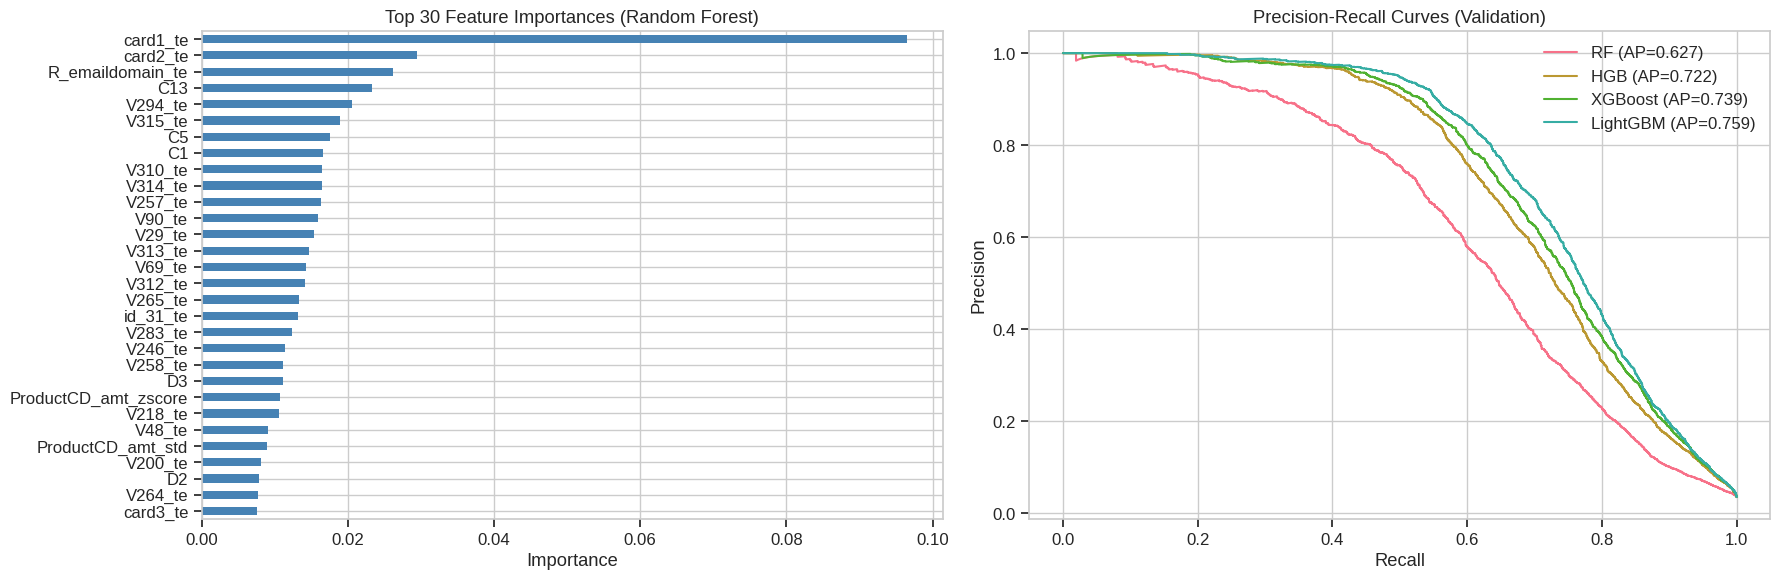

phase1_results.png saved ✓


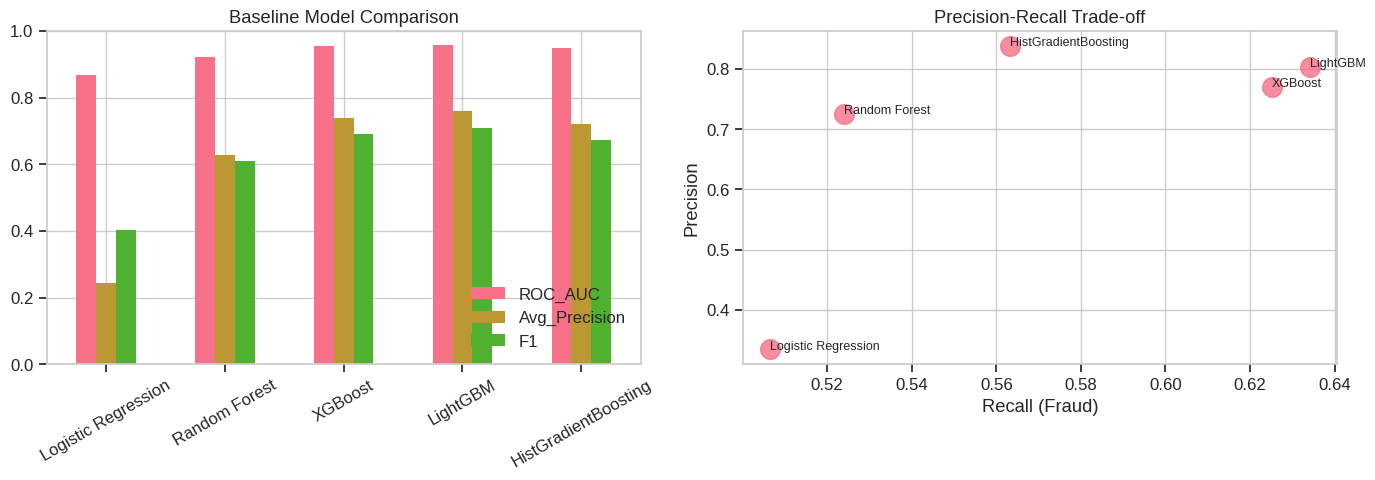

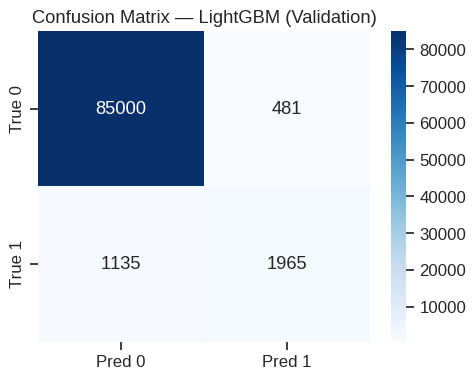

confusion_phase1.png saved ✓


In [11]:

# ── RF Feature Importance ─────────────────────────────────────────────────────
fi_series = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top30 = fi_series.head(30)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top30.plot.barh(ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 30 Feature Importances (Random Forest)')
axes[0].set_xlabel('Importance')

model_map = [('RF', rf, X_val_qt), ('HGB', gbm, X_val_qt)]
if XGB_OK: model_map.append(('XGBoost', xgb_model, X_val_qt))
if LGB_OK: model_map.append(('LightGBM', lgb_model, X_val_qt))

for name, mdl, Xv in model_map:
    prob = mdl.predict_proba(Xv)[:,1]
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ap = average_precision_score(y_val, prob)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})')

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (Validation)')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase1_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('phase1_results.png saved ✓')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline_df[['ROC_AUC','Avg_Precision','F1']].plot.bar(ax=axes[0])
axes[0].set_title('Baseline Model Comparison'); axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30); axes[0].set_ylim(0, 1)

axes[1].scatter(baseline_df['Recall_Fraud'], baseline_df['Precision'], s=200, alpha=0.8)
for idx, row in baseline_df.iterrows():
    axes[1].annotate(idx, (row['Recall_Fraud'], row['Precision']), fontsize=9)
axes[1].set_xlabel('Recall (Fraud)'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Trade-off')
plt.tight_layout()
plt.savefig('phase1_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best_clf_name = baseline_df['F1'].idxmax()
best_clf_map = {'XGBoost': xgb_model, 'LightGBM': lgb_model,
                'Random Forest': rf, 'HistGradientBoosting': gbm,
                'Logistic Regression': lr}
best_clf = best_clf_map.get(best_clf_name, rf)
best_thresh = baseline_df.loc[best_clf_name, 'Threshold']
best_prob = best_clf.predict_proba(X_val_qt)[:,1]
best_pred = (best_prob >= best_thresh).astype(int)

cm = confusion_matrix(y_val, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title(f'Confusion Matrix — {best_clf_name} (Validation)')
plt.tight_layout(); plt.savefig('confusion_phase1.png', dpi=120, bbox_inches='tight')
plt.show(); print('confusion_phase1.png saved ✓')


---
# Phase 2: Generative Fraud Synthesis

**Key architectural change from v2**: feature engineering now happens **after** generation,
not before. The generator pipeline is:

```
Real fraud (raw, minimally cleaned)
      │
      ▼
Select 80 informative features   (GENERATOR_FEATURE_COLS from Section 7)
      │
      ▼
Normalize (QuantileTransformer, fit on generator-feature fraud rows only)
      │
      ▼
Train 5 generators:  β-CVAE · CTGAN · TVAE · Gaussian Copula · CopulaGAN (optional)
      │
      ▼
Generate fraud samples
      │
      ▼
Phase 2.5: Validate  (statistical similarity, C2ST, diversity, composite quality score)
      │
      ▼
Filter  (5-detector majority-vote outlier removal)
      │
      ▼
Feature-engineer the surviving synthetic rows using the SAME modular functions from
Section 5, so synthetic and real fraud go through identical downstream feature logic
      │
      ▼
Merge with real data at an ADAPTIVELY SEARCHED augmentation ratio (not a fixed 30%)
```

Working on the reduced, high-signal feature set (rather than the full ~310) keeps every
generator's input dimensionality tractable and focuses model capacity on the columns that
actually separate fraud from non-fraud.


## 12. Isolate Fraud Class & Prepare Generator-Facing Data

In [12]:

t0 = time.time()

# ── 12.1 Select generator features from the ORIGINAL (pre-final-encoding) frame ──
# GENERATOR_FEATURE_COLS was chosen against the full classifier feature set (Section 7),
# so it is already a subset of FEATURE_COLS / df.columns.
fraud_mask = (y_train == 1)

# Map generator feature names to their column index in FEATURE_COLS / X_train
feat_to_idx = {c: i for i, c in enumerate(FEATURE_COLS)}
GEN_IDX = [feat_to_idx[c] for c in GENERATOR_FEATURE_COLS if c in feat_to_idx]
GENERATOR_FEATURE_COLS = [FEATURE_COLS[i] for i in GEN_IDX]  # keep order consistent

X_fraud_raw_full  = X_train[fraud_mask]                  # all classifier features, raw
X_fraud_gen_raw   = X_fraud_raw_full[:, GEN_IDX]          # generator-only features, raw
fraud_df_raw_full = pd.DataFrame(X_fraud_raw_full, columns=FEATURE_COLS)
fraud_df_gen_raw  = pd.DataFrame(X_fraud_gen_raw, columns=GENERATOR_FEATURE_COLS)

# ── 12.2 Normalize (fit strictly on the generator-feature fraud rows) ────────
qt_gen = QuantileTransformer(output_distribution='normal', random_state=SEED)
X_fraud_gen_qt = qt_gen.fit_transform(X_fraud_gen_raw)

INPUT_DIM = X_fraud_gen_qt.shape[1]
bin_cols  = [i for i, c in enumerate(GENERATOR_FEATURE_COLS) if fraud_df_gen_raw[c].nunique() <= 2]
cont_cols = [i for i in range(INPUT_DIM) if i not in bin_cols]
BIN_IDX, CONT_IDX = bin_cols, cont_cols

print(f'Fraud samples (train)     : {X_fraud_gen_qt.shape[0]:,}')
print(f'Generator feature dim     : {INPUT_DIM}  (reduced from {len(FEATURE_COLS)} classifier features)')
print(f'Continuous / Binary       : {len(CONT_IDX)} / {len(BIN_IDX)}')

log_experiment('generator_data_prep', phase='phase2',
               config={'n_generator_features': INPUT_DIM, 'n_fraud_train': int(fraud_mask.sum())},
               timing_s=time.time()-t0,
               notes='feature engineering deferred until after generation, per improved pipeline')


Fraud samples (train)     : 14,464
Generator feature dim     : 80  (reduced from 414 classifier features)
Continuous / Binary       : 77 / 3


{'timestamp': '2026-07-09T09:46:30.877265',
 'phase': 'phase2',
 'experiment': 'generator_data_prep',
 'seed': 42,
 'config': '{"n_generator_features": 80, "n_fraud_train": 14464}',
 'timing_s': 0.37,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': 'feature engineering deferred until after generation, per improved pipeline'}

## 13. β-CVAE Architecture (with KL Annealing)

In [13]:

class BetaCVAE(nn.Module):
    '''Beta-Constrained VAE for mixed-type tabular fraud data.
    Residual MLP blocks + BatchNorm/LayerNorm, as specified in the improved plan.'''

    def __init__(self, input_dim, hidden_dims, latent_dim, bin_idx, cont_idx,
                 use_layernorm=True, dropout=0.1):
        super().__init__()
        self.bin_idx, self.cont_idx = bin_idx, cont_idx
        self.latent_dim, self.input_dim = latent_dim, input_dim

        # ── Encoder: residual MLP blocks ──────────────────────────────────────
        self.enc_in = nn.Linear(input_dim, hidden_dims[0])
        self.enc_blocks = nn.ModuleList()
        prev = hidden_dims[0]
        for h in hidden_dims:
            block = nn.ModuleDict({
                'fc1': nn.Linear(prev, h),
                'bn1': nn.BatchNorm1d(h),
                'ln1': nn.LayerNorm(h) if use_layernorm else nn.Identity(),
                'fc2': nn.Linear(h, h),
                'bn2': nn.BatchNorm1d(h),
                'proj': nn.Linear(prev, h) if prev != h else nn.Identity(),
            })
            self.enc_blocks.append(block)
            prev = h
        self.enc_dropout = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # ── Decoder: mirrored residual MLP blocks ────────────────────────────
        self.dec_in = nn.Linear(latent_dim, hidden_dims[-1])
        self.dec_blocks = nn.ModuleList()
        prev = hidden_dims[-1]
        for h in reversed(hidden_dims):
            block = nn.ModuleDict({
                'fc1': nn.Linear(prev, h),
                'bn1': nn.BatchNorm1d(h),
                'ln1': nn.LayerNorm(h) if use_layernorm else nn.Identity(),
                'fc2': nn.Linear(h, h),
                'bn2': nn.BatchNorm1d(h),
                'proj': nn.Linear(prev, h) if prev != h else nn.Identity(),
            })
            self.dec_blocks.append(block)
            prev = h
        self.dec_dropout = nn.Dropout(dropout)
        self.out_cont = nn.Linear(prev, len(cont_idx)) if cont_idx else None
        self.out_bin  = nn.Linear(prev, len(bin_idx))  if bin_idx  else None

    @staticmethod
    def _residual_block(x, block):
        identity = block['proj'](x)
        h = F.gelu(block['bn1'](block['fc1'](x)))
        h = block['ln1'](h)
        h = block['bn2'](block['fc2'](h))
        return F.gelu(h + identity)

    def encode(self, x):
        h = F.gelu(self.enc_in(x))
        for block in self.enc_blocks:
            h = self._residual_block(h, block)
        h = self.enc_dropout(h)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def decode(self, z, return_logits=False):
        '''
        Decode a latent code back to feature space.

        By default returns PROBABILITIES for binary columns (sigmoid already
        applied) — this is what every sampling/generation call site expects
        (Section 15.1 BetaCVAE sampling, etc), so the public contract is
        unchanged.

        Pass return_logits=True (used internally by forward() during training)
        to additionally get the pre-sigmoid logits for the binary columns, so
        the loss can use the autocast-safe BCEWithLogitsLoss instead of
        BCELoss(sigmoid(x)) — plain nn.BCELoss on sigmoid-activated input is
        explicitly unsafe under torch.cuda.amp.autocast() and raises a
        RuntimeError ("binary_cross_entropy and BCELoss are unsafe to
        autocast").
        '''
        h = F.gelu(self.dec_in(z))
        for block in self.dec_blocks:
            h = self._residual_block(h, block)
        h = self.dec_dropout(h)
        # dtype must match h's dtype (float16 under autocast, float32 otherwise) —
        # hardcoding float32 here causes 'Index put requires the source and
        # destination dtypes match' under torch.cuda.amp.autocast().
        out = torch.zeros(z.size(0), self.input_dim, device=z.device, dtype=h.dtype)
        bin_logits = None
        if self.cont_idx:
            out[:, self.cont_idx] = self.out_cont(h)
        if self.bin_idx:
            bin_logits = self.out_bin(h)
            out[:, self.bin_idx] = torch.sigmoid(bin_logits)
        if return_logits:
            return out, bin_logits
        return out

    def forward(self, x):
        mu, logvar = self.encode(x)
        recon, bin_logits = self.decode(self.reparameterize(mu, logvar), return_logits=True)
        return recon, mu, logvar, bin_logits


def vae_loss(recon, x, mu, logvar, beta, bin_idx, cont_idx, bin_logits=None):
    '''Mixed MSE (continuous) + BCE (binary) + KL with beta weighting.

    Binary term uses BCEWithLogitsLoss on the pre-sigmoid logits (bin_logits)
    rather than BCELoss on the already-sigmoided `recon` slice, since plain
    BCELoss-on-sigmoid-output is unsafe under mixed precision (autocast). If
    bin_logits isn't supplied (e.g. when scoring an externally-produced
    `recon` that only has probabilities), falls back to a numerically-clamped
    BCELoss so the function still works outside the training loop.
    '''
    loss = torch.tensor(0., device=x.device)
    if cont_idx:
        loss += nn.MSELoss()(recon[:, cont_idx], x[:, cont_idx])
    if bin_idx:
        target = x[:, bin_idx].clamp(0, 1)
        if bin_logits is not None:
            loss += nn.BCEWithLogitsLoss()(bin_logits, target)
        else:
            eps = 1e-6
            probs = recon[:, bin_idx].clamp(eps, 1 - eps)
            loss += nn.BCELoss()(probs, target)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return loss + beta * kl, loss.item(), kl.item()


def kl_annealing(epoch, warmup_epochs=50, max_beta=1.0):
    '''Linear KL annealing (β warmup): ramp from 0 to max_beta over warmup_epochs.'''
    return min(max_beta, max_beta * epoch / max(warmup_epochs, 1))


print('β-CVAE (residual MLP, BatchNorm+LayerNorm, KL annealing, autocast-safe BCE) defined ✓')


β-CVAE (residual MLP, BatchNorm+LayerNorm, KL annealing, autocast-safe BCE) defined ✓


## 14. Hyperparameter Search & β-CVAE Training

Uses cosine LR scheduling, gradient clipping, mixed precision (when on GPU), and
early stopping on top of the KL-annealed training loop, matching the improved plan's
generator tuning checklist.


In [14]:

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.synchronize()
    VAE_DEVICE = 'cuda'
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    VAE_DEVICE = 'cpu'
    print('Using CPU')

LATENT_DIM_GRID = [64]          # per plan: latent dimension 64
BETA_GRID       = [0.1, 0.5, 1.0]
HIDDEN_DIMS     = [256, 128, 64]
BATCH_SIZE      = 256
EPOCHS          = 300
LR              = 5e-4
KL_WARMUP       = 80
EARLY_STOP_PATIENCE = 40
USE_AMP         = (VAE_DEVICE == 'cuda')

fraud_tensor = torch.FloatTensor(X_fraud_gen_qt)
loader = DataLoader(TensorDataset(fraud_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

best_loss, best_params, best_model_state, best_history = float('inf'), {}, None, []
best_recon_history, best_kl_history = [], []
search_records = []

print(f'\nHP search over {len(LATENT_DIM_GRID)*len(BETA_GRID)} configs …')
print('='*70)
t_vae_search = time.time()

scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

for ld in LATENT_DIM_GRID:
    for beta_max in BETA_GRID:
        t0 = time.time()
        model = BetaCVAE(INPUT_DIM, HIDDEN_DIMS, ld, BIN_IDX, CONT_IDX).to(VAE_DEVICE)
        opt   = optim.Adam(model.parameters(), lr=LR)
        # Cosine LR schedule (per plan) instead of plateau-only reduction
        sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=60, T_mult=1, eta_min=LR*0.05)

        history, recon_history, kl_history, failed = [], [], [], False
        best_epoch_loss, epochs_no_improve = float('inf'), 0

        for ep in range(1, EPOCHS+1):
            model.train()
            ep_loss = ep_recon = ep_kl = 0.
            beta_cur = kl_annealing(ep, KL_WARMUP, beta_max)
            for (batch,) in loader:
                batch = batch.to(VAE_DEVICE)
                opt.zero_grad()
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    recon, mu, logvar, bin_logits = model(batch)
                    loss, recon_val, kl_val = vae_loss(recon, batch, mu, logvar, beta_cur, BIN_IDX, CONT_IDX,
                                                        bin_logits=bin_logits)
                if torch.isnan(loss) or torch.isinf(loss): failed=True; break
                scaler_amp.scale(loss).backward()
                scaler_amp.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler_amp.step(opt)
                scaler_amp.update()
                ep_loss  += loss.item()
                ep_recon += recon_val
                ep_kl    += kl_val
            if failed: break
            sched.step(ep)
            n_batches = len(loader)
            avg = ep_loss / n_batches
            history.append(avg)
            recon_history.append(ep_recon / n_batches)
            kl_history.append(ep_kl / n_batches)

            # Early stopping on the annealed total loss
            if avg < best_epoch_loss - 1e-4:
                best_epoch_loss = avg
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOP_PATIENCE and ep > KL_WARMUP + 20:
                print(f'  LD={ld}  β_max={beta_max}  early stop at ep {ep} (no improvement for {EARLY_STOP_PATIENCE} epochs)')
                break

            if ep % 150 == 0:
                print(f'  LD={ld}  β_max={beta_max}  Ep {ep}/{EPOCHS}  Loss: {avg:.4f}  '
                      f'Recon: {recon_history[-1]:.4f}  KL: {kl_history[-1]:.4f}  Time: {time.time()-t0:.0f}s')

        final = np.mean(history[-30:]) if history and not failed else float('inf')
        elapsed = time.time()-t0
        search_records.append({'latent_dim':ld,'beta':beta_max,'final_loss':round(final,4),
                               'epochs':len(history),'time_s':round(elapsed,1)})
        print(f'→ LD={ld}  β={beta_max}  loss={final:.4f}  epochs={len(history)}  time={elapsed:.0f}s')

        if final < best_loss:
            best_loss, best_params = final, {'latent_dim':ld,'beta':beta_max}
            best_model_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            best_history = history
            best_recon_history = recon_history
            best_kl_history = kl_history
        del model; gc.collect()

# Reconstruct best model
LATENT_DIM = best_params['latent_dim']
BETA       = best_params['beta']
best_model = BetaCVAE(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM, BIN_IDX, CONT_IDX)
best_model.load_state_dict(best_model_state)
best_model = best_model.to(VAE_DEVICE)

search_df = pd.DataFrame(search_records).sort_values('final_loss')
print(f'\n{"="*70}')
print(f'✅ Best: LATENT_DIM={LATENT_DIM}  β={BETA}  Loss={best_loss:.4f}')
print(f'{"="*70}')
print(search_df.to_string(index=False))

log_experiment('beta_cvae_hp_search', phase='phase2',
               config={'latent_dim_grid': LATENT_DIM_GRID, 'beta_grid': BETA_GRID,
                       'hidden_dims': HIDDEN_DIMS, 'kl_warmup': KL_WARMUP, 'amp': USE_AMP},
               timing_s=time.time()-t_vae_search,
               quality_metrics={'best_loss': best_loss, 'best_latent_dim': LATENT_DIM, 'best_beta': BETA})


Using GPU: Tesla T4

HP search over 3 configs …
  LD=64  β_max=0.1  early stop at ep 101 (no improvement for 40 epochs)
→ LD=64  β=0.1  loss=1.5147  epochs=101  time=83s
  LD=64  β_max=0.5  early stop at ep 101 (no improvement for 40 epochs)
→ LD=64  β=0.5  loss=2.5028  epochs=101  time=82s
  LD=64  β_max=1.0  early stop at ep 101 (no improvement for 40 epochs)
→ LD=64  β=1.0  loss=2.8782  epochs=101  time=82s

✅ Best: LATENT_DIM=64  β=0.1  Loss=1.5147
 latent_dim  beta  final_loss  epochs  time_s
         64   0.1      1.5147     101    82.8
         64   0.5      2.5028     101    81.8
         64   1.0      2.8782     101    81.5


{'timestamp': '2026-07-09T09:50:39.109642',
 'phase': 'phase2',
 'experiment': 'beta_cvae_hp_search',
 'seed': 42,
 'config': '{"latent_dim_grid": [64], "beta_grid": [0.1, 0.5, 1.0], "hidden_dims": [256, 128, 64], "kl_warmup": 80, "amp": true}',
 'timing_s': 247.61,
 'memory_mb': None,
 'quality_metrics': '{"best_loss": 1.5147021930132594, "best_latent_dim": 64, "best_beta": 0.1}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': ''}

## 14b. β-CVAE Convergence Diagnostics

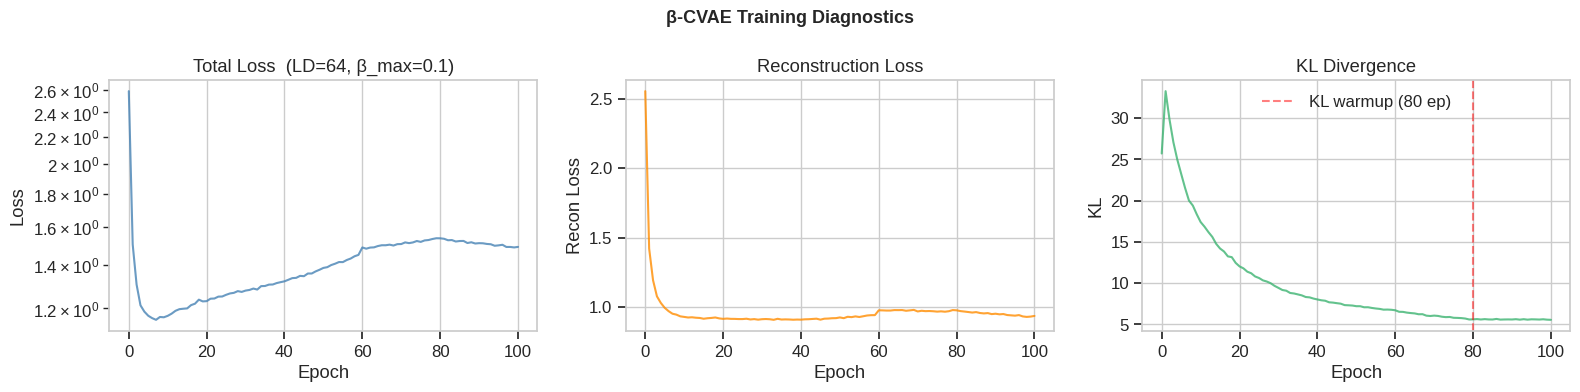

vae_training_diagnostics.png saved ✓

=== CONVERGENCE CHECK ===
Reconstruction loss : ✓ converged  (improvement: 5.7%,  late std: 0.0146)
KL divergence       : ✓ converged  (improvement: 66.0%,  late std: 0.1214)

✅ β-CVAE CONVERGED — will be used as primary generator (pending Phase 2.5 validation)


{'timestamp': '2026-07-09T09:50:40.123975',
 'phase': 'phase2',
 'experiment': 'beta_cvae_convergence',
 'seed': 42,
 'config': '{}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{"converged": true, "recon_msg": "\\u2713 converged  (improvement: 5.7%,  late std: 0.0146)", "kl_msg": "\\u2713 converged  (improvement: 66.0%,  late std: 0.1214)"}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': ''}

In [15]:

# ── Loss curve plot: total, reconstruction, KL ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(best_history, color='steelblue', alpha=0.8)
axes[0].set_title(f'Total Loss  (LD={LATENT_DIM}, β_max={BETA})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_yscale('log')

axes[1].plot(best_recon_history, color='darkorange', alpha=0.8)
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Recon Loss')

axes[2].plot(best_kl_history, color='mediumseagreen', alpha=0.8)
axes[2].axvline(KL_WARMUP, color='red', linestyle='--', alpha=0.5, label=f'KL warmup ({KL_WARMUP} ep)')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('KL'); axes[2].legend()

plt.suptitle('β-CVAE Training Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vae_training_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()
print('vae_training_diagnostics.png saved ✓')

# ── Convergence verdict ────────────────────────────────────────────────────────
def check_convergence(history, window=30, improvement_threshold=0.005):
    if len(history) < window * 2:
        return False, 'insufficient epochs'
    early_mean = np.mean(history[:window])
    late_mean  = np.mean(history[-window:])
    late_std   = np.std(history[-window:])
    relative_improvement = (early_mean - late_mean) / (early_mean + 1e-9)
    if relative_improvement < improvement_threshold:
        return False, f'loss barely changed (rel. improvement: {relative_improvement:.3f})'
    if late_std / (late_mean + 1e-9) > 0.05:
        return False, f'late-window unstable (CV={late_std/(late_mean+1e-9):.3f})'
    return True, f'✓ converged  (improvement: {relative_improvement*100:.1f}%,  late std: {late_std:.4f})'

recon_ok, recon_msg = check_convergence(best_recon_history)
kl_ok,    kl_msg    = check_convergence(best_kl_history)

print('\n=== CONVERGENCE CHECK ===')
print(f'Reconstruction loss : {recon_msg}')
print(f'KL divergence       : {kl_msg}')

VAE_CONVERGED = recon_ok and kl_ok
if VAE_CONVERGED:
    print('\n✅ β-CVAE CONVERGED — will be used as primary generator (pending Phase 2.5 validation)')
else:
    print('\n⚠️  β-CVAE DID NOT CONVERGE — pipeline will rely on Phase 2.5 quality scores to pick a fallback')
    print('   Recommendation: try longer warmup, lower LR, or use CTGAN/Copula as primary.')

log_experiment('beta_cvae_convergence', phase='phase2',
               quality_metrics={'converged': VAE_CONVERGED, 'recon_msg': recon_msg, 'kl_msg': kl_msg})


## 15. Synthetic Fraud Generation — All 5 Generators

Each SDV-based generator (CTGAN, TVAE, Gaussian Copula, CopulaGAN) is now explicitly
tuned instead of run with library defaults, per the improved plan:

| Generator | Tuned hyperparameters |
|---|---|
| CTGAN | epochs, batch_size, embedding_dim, generator/discriminator layer widths, pac, learning rates |
| TVAE | latent (embedding) dim, compress_dims, decompress_dims, epochs, learning rate |
| Gaussian Copula | simple statistical baseline — minimal tuning surface, included as a fast/robust fallback |
| CopulaGAN (optional) | same tunables as CTGAN plus the copula transform; run only if SDV supports it |

All generators are trained on the reduced generator-feature set produced in Section 12
(top ~80 features), on raw (unscaled) fraud rows — the β-CVAE works on the scaled version
via `qt_gen`; the SDV models work with their own internal transforms on the raw features.


In [16]:

t_gen_all = time.time()
N_SYNTH = n_real_fraud * 3  # ~3× fraud pool, same target volume as before

print('Step 1/6: Preparing generator-feature data for SDV models...')
fraud_df_gen_clean = fraud_df_gen_raw.copy()
for col in fraud_df_gen_clean.columns:
    if fraud_df_gen_clean[col].dtype == 'object':
        top_vals = fraud_df_gen_clean[col].value_counts().head(10).index
        fraud_df_gen_clean[col] = fraud_df_gen_clean[col].apply(lambda x: x if x in top_vals else 'other')
    else:
        lower = fraud_df_gen_clean[col].quantile(0.01)
        upper = fraud_df_gen_clean[col].quantile(0.99)
        fraud_df_gen_clean[col] = fraud_df_gen_clean[col].clip(lower, upper).fillna(0)
print(f'   Data ready: {fraud_df_gen_clean.shape}')

generator_timings = {}

# ── 15.1 β-CVAE Sampling ───────────────────────────────────────────────────────
print('\nStep 2/6: Generating β-CVAE samples...')
t0 = time.time()
best_model.eval()
with torch.no_grad():
    mu_enc, logvar_enc = best_model.encode(fraud_tensor.to(VAE_DEVICE))
    z_mean = mu_enc.mean(0)
    z_std = (0.5 * logvar_enc).exp().mean(0)

synth_vae_list = []
with torch.no_grad():
    batch_size = 1024
    while len(synth_vae_list) * batch_size < N_SYNTH:
        z = torch.normal(z_mean.expand(batch_size, -1), z_std.expand(batch_size, -1)).to(VAE_DEVICE)
        synth_vae_list.append(best_model.decode(z).cpu().numpy())

synth_vae_qt = np.vstack(synth_vae_list)[:N_SYNTH]
synth_vae_df = pd.DataFrame(qt_gen.inverse_transform(synth_vae_qt), columns=GENERATOR_FEATURE_COLS)
generator_timings['BetaCVAE'] = time.time() - t0
print(f'   β-CVAE: {len(synth_vae_df):,} samples ✓ ({generator_timings["BetaCVAE"]:.1f}s)')

# ── 15.2 SDV Models ────────────────────────────────────────────────────────────
ctgan_synth_df = tvae_synth_df = copula_synth_df = copulagan_synth_df = None

if SDV_OK:
    sample_size = min(10000, len(fraud_df_gen_clean))
    train_sample = fraud_df_gen_clean.sample(sample_size, random_state=SEED)
    print(f'\n   Using {sample_size}/{len(fraud_df_gen_clean)} samples for SDV training')

    meta = SingleTableMetadata()
    meta.detect_from_dataframe(train_sample)

    # ── CTGAN — tuned (epochs, batch, embedding, layers, pac, LR) ────────────
    print('\nStep 3/6: Training CTGAN (tuned) …')
    t0 = time.time()
    try:
        ctgan = CTGANSynthesizer(
            metadata=meta,
            epochs=300,
            batch_size=500,
            embedding_dim=128,
            generator_dim=(256, 256),
            discriminator_dim=(256, 256),
            generator_lr=2e-4, discriminator_lr=2e-4,
            generator_decay=1e-6, discriminator_decay=1e-6,
            discriminator_steps=1,
            pac=10,
            log_frequency=False, verbose=False,
        )
        ctgan.fit(train_sample)
        ctgan_synth_df = ctgan.sample(N_SYNTH)
        generator_timings['CTGAN'] = time.time() - t0
        print(f'   CTGAN: {len(ctgan_synth_df):,} samples ✓ ({generator_timings["CTGAN"]:.1f}s)')
    except Exception as e:
        print(f'   CTGAN failed: {str(e)[:120]}')

    # ── TVAE — tuned (latent dim, compress/decompress dims, epochs, LR) ──────
    print('\nStep 4/6: Training TVAE (tuned) …')
    t0 = time.time()
    try:
        tvae = TVAESynthesizer(
            metadata=meta,
            epochs=250,
            batch_size=500,
            embedding_dim=128,
            compress_dims=(128, 128),
            decompress_dims=(128, 128),
            l2scale=1e-5,
            loss_factor=2,
            verbose=False,
        )
        tvae.fit(train_sample)
        tvae_synth_df = tvae.sample(N_SYNTH)
        generator_timings['TVAE'] = time.time() - t0
        print(f'   TVAE: {len(tvae_synth_df):,} samples ✓ ({generator_timings["TVAE"]:.1f}s)')
    except Exception as e:
        print(f'   TVAE failed: {e}')

    # ── Gaussian Copula — simple statistical baseline ─────────────────────────
    print('\nStep 5/6: Training Gaussian Copula (baseline) …')
    t0 = time.time()
    try:
        copula = GaussianCopulaSynthesizer(metadata=meta)
        copula.fit(train_sample)
        copula_synth_df = copula.sample(N_SYNTH)
        generator_timings['GaussianCopula'] = time.time() - t0
        print(f'   Copula: {len(copula_synth_df):,} samples ✓ ({generator_timings["GaussianCopula"]:.1f}s)')
    except Exception as e:
        print(f'   Copula failed: {e}')

    # ── CopulaGAN — optional 5th generator ────────────────────────────────────
    print('\nStep 6/6: Training CopulaGAN (optional) …')
    t0 = time.time()
    try:
        copulagan = CopulaGANSynthesizer(
            metadata=meta,
            epochs=300, batch_size=500,
            generator_dim=(256, 256), discriminator_dim=(256, 256),
            generator_lr=2e-4, discriminator_lr=2e-4,
            verbose=False,
        )
        copulagan.fit(train_sample)
        copulagan_synth_df = copulagan.sample(N_SYNTH)
        generator_timings['CopulaGAN'] = time.time() - t0
        print(f'   CopulaGAN: {len(copulagan_synth_df):,} samples ✓ ({generator_timings["CopulaGAN"]:.1f}s)')
    except Exception as e:
        print(f'   CopulaGAN not available / failed: {str(e)[:120]}')
        copulagan_synth_df = None

    if all(x is None for x in [ctgan_synth_df, tvae_synth_df, copula_synth_df, copulagan_synth_df]):
        print('\n   All SDV models failed. Using bootstrap fallback...')
        bootstrap_indices = np.random.choice(len(fraud_df_gen_clean), N_SYNTH, replace=True)
        bootstrap_df = fraud_df_gen_clean.iloc[bootstrap_indices].copy()
        for col in bootstrap_df.select_dtypes(include=[np.number]).columns:
            noise_std = bootstrap_df[col].std() * 0.01
            bootstrap_df[col] += np.random.normal(0, noise_std, len(bootstrap_df))
        ctgan_synth_df = bootstrap_df
        print(f'   Bootstrap: {len(ctgan_synth_df):,} samples ✓')
else:
    print('\n[WARN] SDV not installed - using only β-CVAE for all downstream generator slots')
    ctgan_synth_df = tvae_synth_df = copula_synth_df = copulagan_synth_df = synth_vae_df.copy()

print('\nGeneration complete for all available generators!')
print('Timings:', {k: f'{v:.1f}s' for k, v in generator_timings.items()})

log_experiment('all_generators_sampling', phase='phase2',
               config={'n_synth_target': N_SYNTH, 'generator_feature_dim': INPUT_DIM},
               timing_s=time.time() - t_gen_all,
               notes=json.dumps({k: round(v,1) for k,v in generator_timings.items()}))

GENERATORS = {
    'BetaCVAE': synth_vae_df,
    'CTGAN': ctgan_synth_df,
    'TVAE': tvae_synth_df,
    'GaussianCopula': copula_synth_df,
    'CopulaGAN': copulagan_synth_df,
}
GENERATORS = {k: v for k, v in GENERATORS.items() if v is not None and len(v) > 0}
print(f'\nAvailable trained generators: {list(GENERATORS.keys())}')


Step 1/6: Preparing generator-feature data for SDV models...
   Data ready: (14464, 80)

Step 2/6: Generating β-CVAE samples...
   β-CVAE: 43,392 samples ✓ (0.5s)

   Using 10000/14464 samples for SDV training

Step 3/6: Training CTGAN (tuned) …
   CTGAN: 43,392 samples ✓ (587.1s)

Step 4/6: Training TVAE (tuned) …
   TVAE: 43,392 samples ✓ (381.3s)

Step 5/6: Training Gaussian Copula (baseline) …
   Copula: 43,392 samples ✓ (39.9s)

Step 6/6: Training CopulaGAN (optional) …
   CopulaGAN: 43,392 samples ✓ (606.7s)

Generation complete for all available generators!
Timings: {'BetaCVAE': '0.5s', 'CTGAN': '587.1s', 'TVAE': '381.3s', 'GaussianCopula': '39.9s', 'CopulaGAN': '606.7s'}

Available trained generators: ['BetaCVAE', 'CTGAN', 'TVAE', 'GaussianCopula', 'CopulaGAN']


---
# Phase 2.5: Synthetic Validation

This stage did not exist in the previous version of the pipeline. Every generator's
50,000-ish fraud samples are now scored on five independent axes before anything is
merged into the training set:

1. **Statistical similarity** — KS (per-feature, avg + max), Wasserstein distance,
   Jensen-Shannon divergence, covariance-matrix distance, correlation-matrix distance
2. **Machine-learning similarity** — Classifier Two-Sample Test (C2ST): train a
   classifier to distinguish real vs. synthetic; AUC≈0.50 is excellent, AUC≈0.95 means
   the generator failed
3. **Visualization** — PCA, UMAP, t-SNE overlays of real vs. synthetic
4. **Diversity** — duplicate ratio, nearest-neighbour distance, coverage, density, novelty
5. **Composite quality score** — a single weighted number per generator so the best one
   can be picked automatically:

```
Score = 0.25·KS + 0.20·Wasserstein + 0.20·C2ST + 0.15·Coverage + 0.10·Density + 0.10·Correlation
```

(each term is first normalized to a 0–1 "goodness" scale, so the composite is directly
comparable across generators and higher is always better).


## 16. Statistical Similarity Metrics

In [17]:

t_val = time.time()

def to_generator_array(synth_df):
    '''Align a generator's raw output frame to GENERATOR_FEATURE_COLS as a float array.'''
    out = pd.DataFrame(index=synth_df.index)
    for col in GENERATOR_FEATURE_COLS:
        if col in synth_df.columns:
            out[col] = pd.to_numeric(synth_df[col], errors='coerce').fillna(0)
        else:
            out[col] = 0.0
    return out[GENERATOR_FEATURE_COLS].values.astype(np.float32)

REAL_GEN_ARR = X_fraud_gen_raw  # real fraud, generator-feature space, raw units

def ks_metrics(synth_arr, real_arr, n_samples=5000):
    '''Per-feature KS statistic; returns (avg, max, per-feature series).'''
    n = min(n_samples, len(real_arr), len(synth_arr))
    scores = {}
    for i, feat in enumerate(GENERATOR_FEATURE_COLS):
        try:
            ks, _ = ks_2samp(real_arr[:n, i], synth_arr[:n, i])
        except Exception:
            ks = 1.0
        scores[feat] = ks
    s = pd.Series(scores)
    return s.mean(), s.max(), s

def wasserstein_metrics(synth_arr, real_arr, n_samples=5000):
    '''Per-feature (normalized) Wasserstein distance — better than KS for continuous vars.'''
    n = min(n_samples, len(real_arr), len(synth_arr))
    scores = {}
    for i, feat in enumerate(GENERATOR_FEATURE_COLS):
        rv, sv = real_arr[:n, i], synth_arr[:n, i]
        scale = (np.std(rv) + 1e-9)
        try:
            w = wasserstein_distance(rv, sv) / scale
        except Exception:
            w = 10.0
        scores[feat] = w
    s = pd.Series(scores)
    return s.mean(), s

def js_divergence_metrics(synth_arr, real_arr, n_bins=30, n_samples=5000):
    '''Jensen-Shannon divergence between histogram-estimated distributions per feature.'''
    n = min(n_samples, len(real_arr), len(synth_arr))
    scores = {}
    for i, feat in enumerate(GENERATOR_FEATURE_COLS):
        rv, sv = real_arr[:n, i], synth_arr[:n, i]
        lo, hi = np.percentile(np.concatenate([rv, sv]), [0.5, 99.5])
        if hi <= lo:
            hi = lo + 1e-6
        r_hist, edges = np.histogram(rv, bins=n_bins, range=(lo, hi), density=True)
        s_hist, _     = np.histogram(sv, bins=n_bins, range=(lo, hi), density=True)
        r_hist = r_hist / (r_hist.sum() + 1e-12) + 1e-12
        s_hist = s_hist / (s_hist.sum() + 1e-12) + 1e-12
        m = 0.5 * (r_hist + s_hist)
        js = 0.5 * entropy(r_hist, m) + 0.5 * entropy(s_hist, m)
        scores[feat] = js
    s = pd.Series(scores)
    return s.mean(), s

def covariance_distance(synth_arr, real_arr):
    '''Frobenius norm of the difference between real and synthetic covariance matrices.'''
    cov_r = np.cov(real_arr, rowvar=False)
    cov_s = np.cov(synth_arr, rowvar=False)
    return float(np.linalg.norm(cov_r - cov_s) / (np.linalg.norm(cov_r) + 1e-9))

def correlation_distance(synth_arr, real_arr):
    '''Frobenius norm of the difference between real and synthetic correlation matrices.'''
    corr_r = np.corrcoef(real_arr, rowvar=False)
    corr_s = np.corrcoef(synth_arr, rowvar=False)
    corr_r = np.nan_to_num(corr_r); corr_s = np.nan_to_num(corr_s)
    return float(np.linalg.norm(corr_r - corr_s) / (np.linalg.norm(corr_r) + 1e-9))

print('Statistical similarity functions defined ✓')
print(f'Evaluating {len(GENERATORS)} generators on {len(GENERATOR_FEATURE_COLS)} features …')


Statistical similarity functions defined ✓
Evaluating 5 generators on 80 features …


## 17. Machine-Learning Similarity — Classifier Two-Sample Test (C2ST)

In [18]:

def classifier_two_sample_test(synth_arr, real_arr, n_samples=5000, n_splits=3):
    '''
    Train a classifier to distinguish real (label 0) from synthetic (label 1).
    AUC ≈ 0.50 → indistinguishable (excellent generator).
    AUC ≈ 0.95+ → trivially distinguishable (generator failed).
    '''
    n = min(n_samples, len(real_arr), len(synth_arr))
    X_c2st = np.vstack([real_arr[:n], synth_arr[:n]])
    y_c2st = np.concatenate([np.zeros(n), np.ones(n)])

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, val_idx in skf.split(X_c2st, y_c2st):
        clf = HistGradientBoostingClassifier(max_iter=150, max_depth=5, random_state=SEED)
        clf.fit(X_c2st[tr_idx], y_c2st[tr_idx])
        prob = clf.predict_proba(X_c2st[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_c2st[val_idx], prob))
    return float(np.mean(aucs))

print('C2ST function defined ✓')


C2ST function defined ✓


## 18. Diversity Metrics — Duplicates, Coverage, Density, Novelty

In [19]:

def diversity_metrics(synth_arr, real_arr, n_samples=3000, k=5):
    '''
    duplicate_ratio : fraction of synthetic rows that are near-exact duplicates of each other
    nn_distance     : mean distance from each synthetic sample to its nearest real neighbour
    coverage        : fraction of real samples that have at least one synthetic sample within
                       their k-th nearest-neighbour real-real distance (does synthetic data
                       "cover" the real manifold?)
    density         : mean number of synthetic points inside each real point's local neighbourhood
                       (over-concentration indicates mode collapse)
    novelty         : mean distance from synthetic points to the nearest real point, normalized
                       by the typical real-real neighbour distance (very low = near-copies,
                       very high = unrealistic/off-manifold)
    '''
    n = min(n_samples, len(real_arr), len(synth_arr))
    R = real_arr[np.random.RandomState(SEED).choice(len(real_arr), n, replace=False)]
    S = synth_arr[np.random.RandomState(SEED).choice(len(synth_arr), n, replace=False)]

    # Duplicate ratio within synthetic set
    nn_s = NearestNeighbors(n_neighbors=2, n_jobs=-1).fit(S)
    d_s, _ = nn_s.kneighbors(S)
    dup_thresh = np.percentile(d_s[:, 1], 1)  # bottom 1% distance as a near-duplicate cutoff
    duplicate_ratio = float((d_s[:, 1] <= max(dup_thresh, 1e-9)).mean())

    # Real-real reference distances (for coverage/novelty normalization)
    nn_r = NearestNeighbors(n_neighbors=k+1, n_jobs=-1).fit(R)
    d_rr, _ = nn_r.kneighbors(R)
    typical_real_nn_dist = np.median(d_rr[:, 1:])

    # Synthetic → real nearest neighbour distance
    d_sr, _ = nn_r.kneighbors(S)
    nn_distance = float(np.mean(d_sr[:, 0]))
    novelty = float(nn_distance / (typical_real_nn_dist + 1e-9))

    # Coverage: fraction of real points that have >=1 synthetic sample within their
    # own k-NN radius (i.e. synthetic data reaches that region of the real manifold)
    nn_s_for_r = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(S)
    d_real_to_synth, _ = nn_s_for_r.kneighbors(R)
    covered = d_real_to_synth[:, 0] <= d_rr[:, k]  # within real point's own k-NN radius
    coverage = float(covered.mean())

    # Density: for each real point, how many synthetic points fall inside its k-NN radius
    counts = []
    tree = NearestNeighbors(radius=np.median(d_rr[:, k]), n_jobs=-1).fit(S)
    for i in range(min(500, n)):  # subsample for speed
        idx = tree.radius_neighbors(R[i:i+1], return_distance=False)[0]
        counts.append(len(idx))
    density = float(np.mean(counts)) if counts else 0.0

    return {
        'duplicate_ratio': duplicate_ratio,
        'nn_distance': nn_distance,
        'coverage': coverage,
        'density': density,
        'novelty': novelty,
    }

print('Diversity metric function defined ✓')


Diversity metric function defined ✓


## 19. Composite Quality Score & Generator Leaderboard

In [20]:

def normalize_goodness(value, good, bad):
    '''
    Map a raw metric to a 0..1 'goodness' score, where `good` maps to 1.0 and `bad` maps to 0.0.
    Handles both 'lower is better' (good < bad) and 'higher is better' (good > bad) metrics.
    '''
    if good == bad:
        return 1.0
    frac = (value - bad) / (good - bad)
    return float(np.clip(frac, 0.0, 1.0))

generator_reports = {}

print('='*90)
print('PHASE 2.5 — SYNTHETIC VALIDATION (per generator)')
print('='*90)

for gen_name, gen_df in GENERATORS.items():
    print(f'\n### {gen_name} ###')
    synth_arr = to_generator_array(gen_df)
    n_eval = min(len(synth_arr), len(REAL_GEN_ARR), 8000)

    # ── Statistical similarity ────────────────────────────────────────────────
    ks_avg, ks_max, ks_per_feat = ks_metrics(synth_arr, REAL_GEN_ARR)
    wass_avg, wass_per_feat     = wasserstein_metrics(synth_arr, REAL_GEN_ARR)
    js_avg, js_per_feat         = js_divergence_metrics(synth_arr, REAL_GEN_ARR)
    cov_dist  = covariance_distance(synth_arr[:n_eval], REAL_GEN_ARR[:n_eval])
    corr_dist = correlation_distance(synth_arr[:n_eval], REAL_GEN_ARR[:n_eval])

    # ── ML similarity (C2ST) ──────────────────────────────────────────────────
    c2st_auc = classifier_two_sample_test(synth_arr, REAL_GEN_ARR)

    # ── Diversity ──────────────────────────────────────────────────────────────
    div = diversity_metrics(synth_arr, REAL_GEN_ARR)

    print(f'  KS avg/max            : {ks_avg:.4f} / {ks_max:.4f}')
    print(f'  Wasserstein avg       : {wass_avg:.4f}')
    print(f'  Jensen-Shannon avg    : {js_avg:.4f}')
    print(f'  Covariance distance   : {cov_dist:.4f}')
    print(f'  Correlation distance  : {corr_dist:.4f}')
    print(f'  C2ST AUC              : {c2st_auc:.4f}  '
          f'({"excellent" if c2st_auc < 0.6 else "acceptable" if c2st_auc < 0.8 else "poor"})')
    print(f'  Diversity             : dup_ratio={div["duplicate_ratio"]:.3f}  '
          f'coverage={div["coverage"]:.3f}  density={div["density"]:.2f}  novelty={div["novelty"]:.3f}')

    # ── Composite quality score ───────────────────────────────────────────────
    # Each raw metric → 0..1 goodness, then weighted-summed per the plan's formula.
    ks_good        = normalize_goodness(ks_avg,     good=0.0,  bad=0.5)
    wass_good      = normalize_goodness(wass_avg,   good=0.0,  bad=2.0)
    c2st_good      = normalize_goodness(c2st_auc,   good=0.5,  bad=1.0)
    coverage_good  = normalize_goodness(div['coverage'], good=1.0, bad=0.0)
    density_good   = normalize_goodness(div['density'],  good=np.median([1]), bad=0.0)  # crude: any nonzero density is fine
    corr_good      = normalize_goodness(corr_dist,  good=0.0,  bad=1.0)

    quality_score = (0.25 * ks_good + 0.20 * wass_good + 0.20 * c2st_good +
                      0.15 * coverage_good + 0.10 * density_good + 0.10 * corr_good)

    generator_reports[gen_name] = {
        'ks_avg': ks_avg, 'ks_max': ks_max, 'wasserstein_avg': wass_avg,
        'js_avg': js_avg, 'covariance_distance': cov_dist, 'correlation_distance': corr_dist,
        'c2st_auc': c2st_auc, **div, 'quality_score': quality_score,
        'ks_per_feature': ks_per_feat, 'array': synth_arr,
    }
    print(f'  → Composite quality score: {quality_score:.4f}')

# ── Leaderboard ────────────────────────────────────────────────────────────────
leaderboard = pd.DataFrame({
    k: {kk: vv for kk, vv in v.items() if kk not in ('ks_per_feature', 'array')}
    for k, v in generator_reports.items()
}).T.sort_values('quality_score', ascending=False)

print('\n' + '='*90)
print('GENERATOR LEADERBOARD (sorted by composite quality score — higher is better)')
print('='*90)
print(leaderboard.round(4).to_string())

BEST_GENERATOR = leaderboard.index[0]
print(f'\n🏆 Best generator: {BEST_GENERATOR}  (quality score = {leaderboard.loc[BEST_GENERATOR, "quality_score"]:.4f})')

leaderboard.to_csv('phase2_5_generator_leaderboard.csv')
log_experiment('phase2_5_validation', phase='phase2.5',
               config={'generators_evaluated': list(GENERATORS.keys())},
               timing_s=time.time()-t_val,
               quality_metrics=leaderboard.to_dict(orient='index'),
               notes=f'best generator = {BEST_GENERATOR}')


PHASE 2.5 — SYNTHETIC VALIDATION (per generator)

### BetaCVAE ###
  KS avg/max            : 0.2496 / 0.4192
  Wasserstein avg       : 0.3568
  Jensen-Shannon avg    : 0.0894
  Covariance distance   : 0.9779
  Correlation distance  : 0.8938
  C2ST AUC              : 1.0000  (poor)
  Diversity             : dup_ratio=0.010  coverage=0.203  density=8.94  novelty=0.254
  → Composite quality score: 0.4306

### CTGAN ###
  KS avg/max            : 0.3263 / 1.0000
  Wasserstein avg       : 0.1624
  Jensen-Shannon avg    : 0.0580
  Covariance distance   : 0.1692
  Correlation distance  : 0.5278
  C2ST AUC              : 1.0000  (poor)
  Diversity             : dup_ratio=0.010  coverage=0.830  density=4.31  novelty=1.507
  → Composite quality score: 0.5423

### TVAE ###
  KS avg/max            : 0.2499 / 1.0000
  Wasserstein avg       : 0.1860
  Jensen-Shannon avg    : 0.0456
  Covariance distance   : 0.0215
  Correlation distance  : 0.4453
  C2ST AUC              : 1.0000  (poor)
  Diversity  

{'timestamp': '2026-07-09T10:18:20.555848',
 'phase': 'phase2.5',
 'experiment': 'phase2_5_validation',
 'seed': 42,
 'config': '{"generators_evaluated": ["BetaCVAE", "CTGAN", "TVAE", "GaussianCopula", "CopulaGAN"]}',
 'timing_s': 44.55,
 'memory_mb': None,
 'quality_metrics': '{"TVAE": {"ks_avg": 0.24986749999999996, "ks_max": 1.0, "wasserstein_avg": 0.18599887827990275, "js_avg": 0.04557932167290252, "covariance_distance": 0.021547017172103614, "correlation_distance": 0.44530964415754515, "c2st_auc": 1.0, "duplicate_ratio": 0.01, "nn_distance": 17916.30957840677, "coverage": 0.8086666666666666, "density": 5.322, "novelty": 0.822380879295786, "quality_score": 0.5832353977562552}, "CopulaGAN": {"ks_avg": 0.30105250000000006, "ks_max": 1.0, "wasserstein_avg": 0.1868052032198319, "js_avg": 0.05868178394786879, "covariance_distance": 0.13020068293488843, "correlation_distance": 0.5414993784428002, "c2st_auc": 1.0, "duplicate_ratio": 0.01, "nn_distance": 27760.923522081524, "coverage": 0.8

## 20. Visualization — PCA, UMAP, t-SNE Overlays

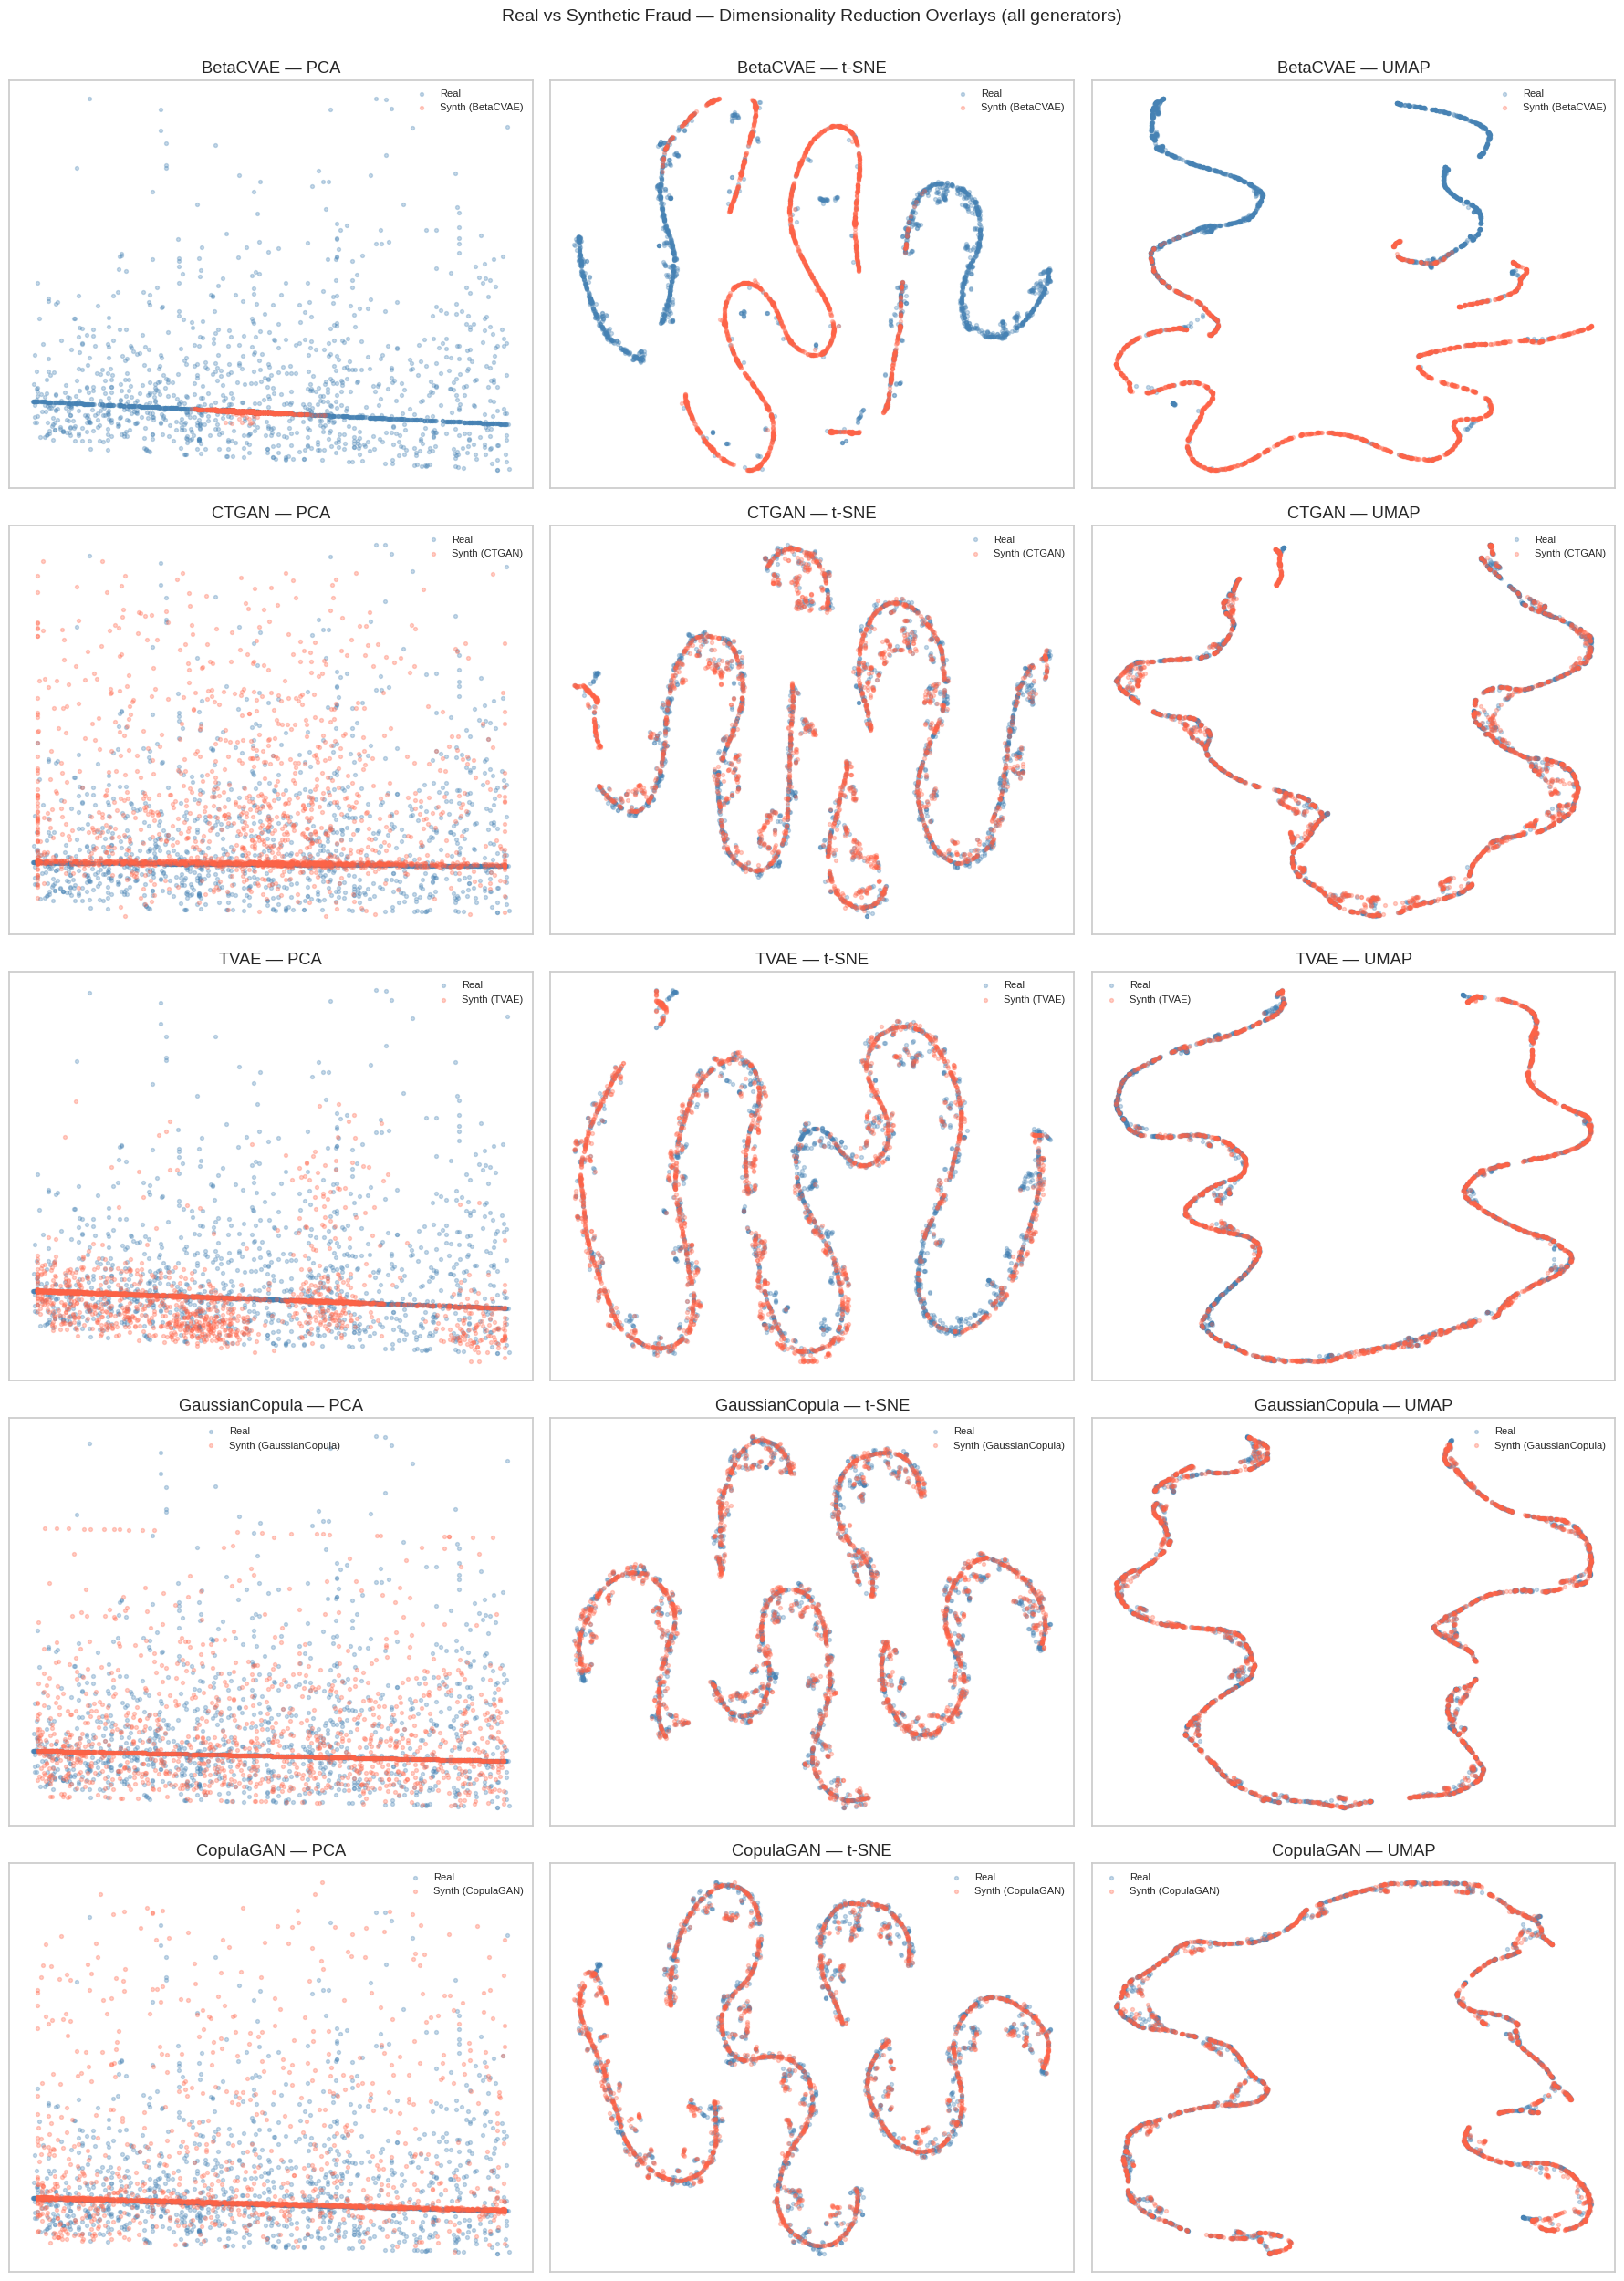

phase2_5_pca_umap_tsne.png saved ✓


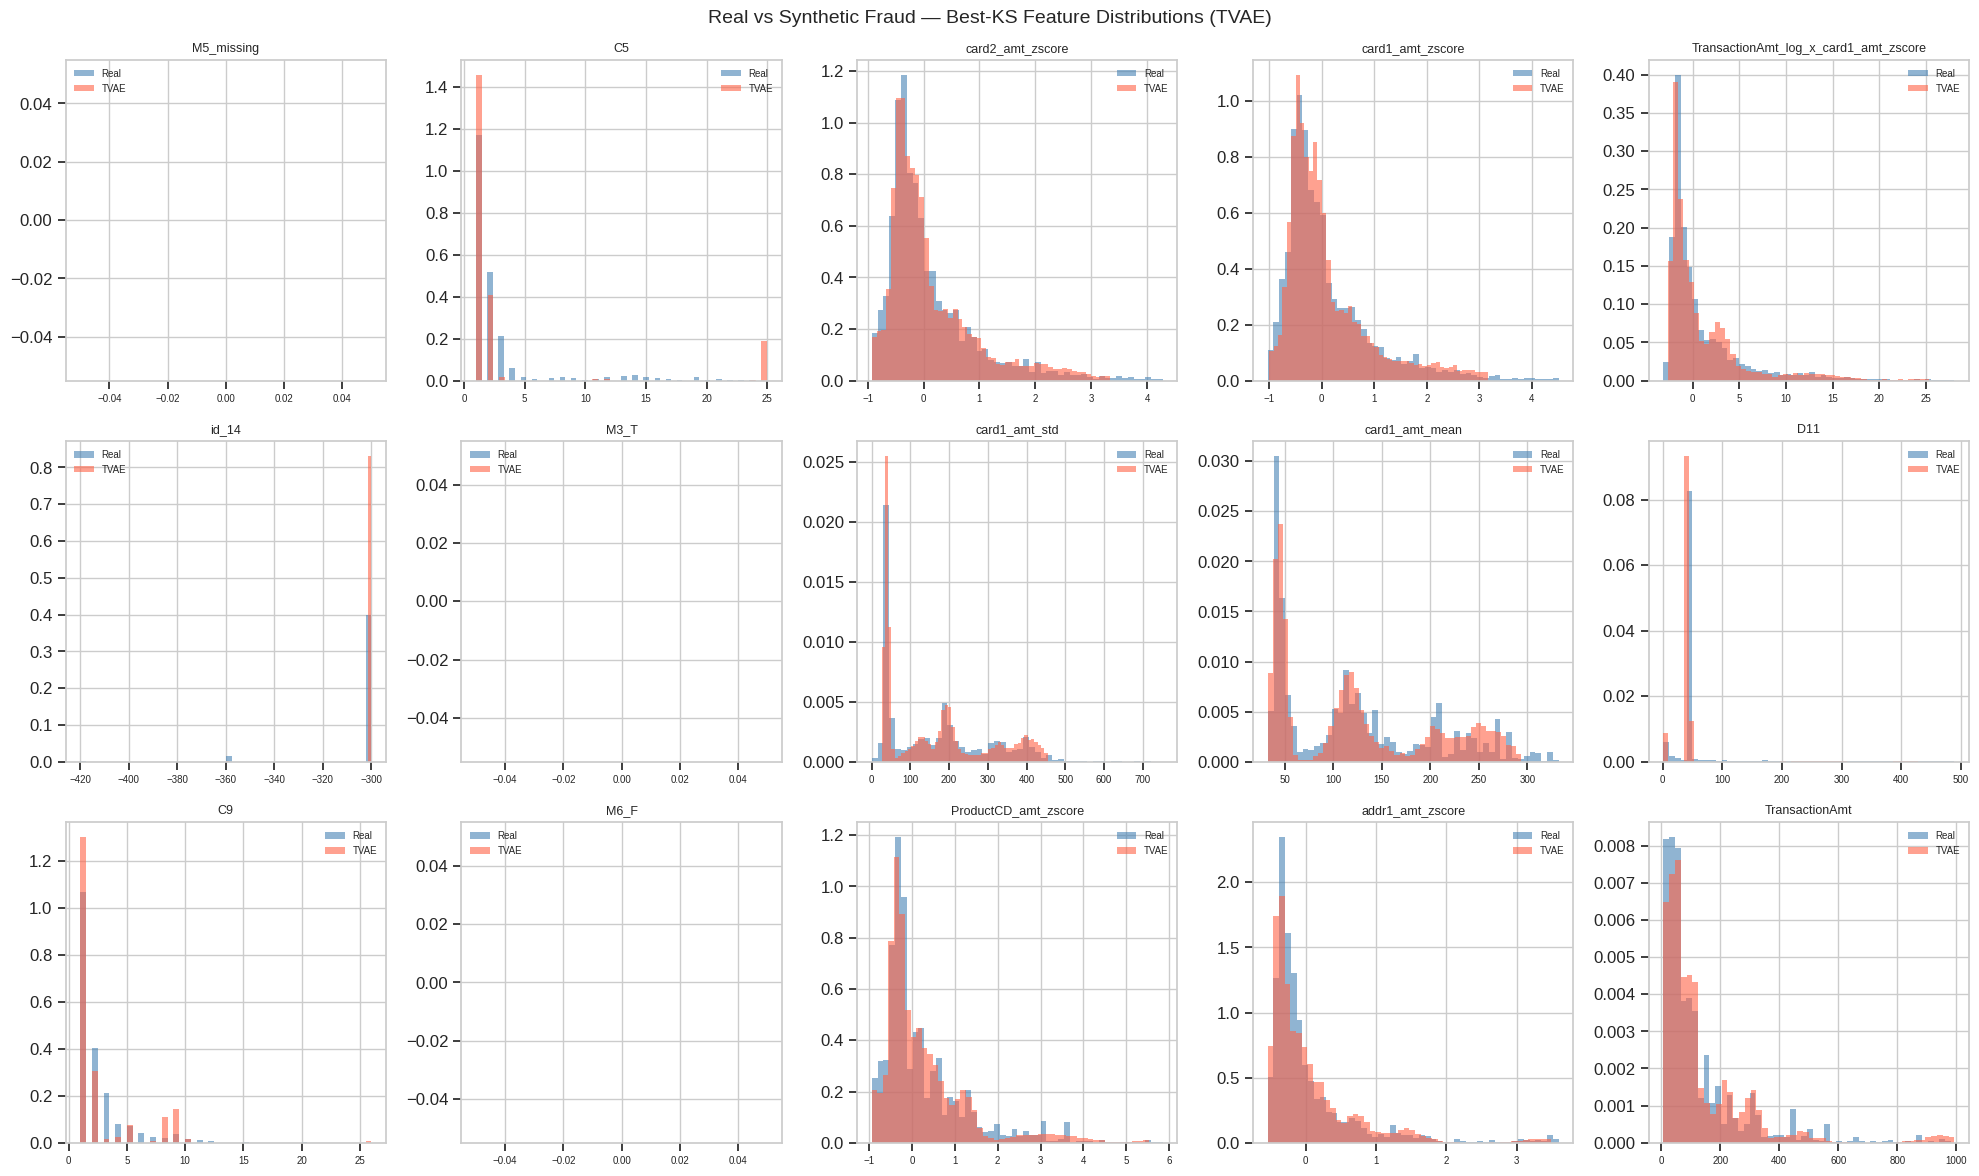

phase2_5_distribution_comparison.png saved ✓


{'timestamp': '2026-07-09T10:21:52.257726',
 'phase': 'phase2.5',
 'experiment': 'phase2_5_visualization',
 'seed': 42,
 'config': '{}',
 'timing_s': 211.68,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': 'plotted 5 generators × PCA/t-SNE/UMAP'}

In [21]:

t0 = time.time()
N_VIS = min(2000, len(REAL_GEN_ARR))

n_gens_to_plot = len(generator_reports)
fig, axes = plt.subplots(n_gens_to_plot, 3 if UMAP_OK else 2,
                          figsize=(6 * (3 if UMAP_OK else 2), 5 * n_gens_to_plot))
if n_gens_to_plot == 1:
    axes = axes.reshape(1, -1)

for row_i, (gen_name, rep) in enumerate(generator_reports.items()):
    synth_arr = rep['array']
    n_s = min(N_VIS, len(synth_arr))
    combined = np.vstack([REAL_GEN_ARR[:N_VIS], synth_arr[:n_s]])

    pca2d = PCA(n_components=2, random_state=SEED).fit_transform(combined)
    ax = axes[row_i, 0]
    ax.scatter(pca2d[:N_VIS, 0], pca2d[:N_VIS, 1], c='steelblue', alpha=0.3, s=8, label='Real')
    ax.scatter(pca2d[N_VIS:, 0], pca2d[N_VIS:, 1], c='tomato', alpha=0.3, s=8, label=f'Synth ({gen_name})')
    ax.set_title(f'{gen_name} — PCA'); ax.legend(fontsize=8); ax.set_xticks([]); ax.set_yticks([])

    pca50 = PCA(n_components=min(50, combined.shape[1]), random_state=SEED).fit_transform(combined)
    tsne2d = TSNE(n_components=2, random_state=SEED, perplexity=35,
                   learning_rate='auto', init='pca').fit_transform(pca50)
    ax = axes[row_i, 1]
    ax.scatter(tsne2d[:N_VIS, 0], tsne2d[:N_VIS, 1], c='steelblue', alpha=0.3, s=8, label='Real')
    ax.scatter(tsne2d[N_VIS:, 0], tsne2d[N_VIS:, 1], c='tomato', alpha=0.3, s=8, label=f'Synth ({gen_name})')
    ax.set_title(f'{gen_name} — t-SNE'); ax.legend(fontsize=8); ax.set_xticks([]); ax.set_yticks([])

    if UMAP_OK:
        reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.1)
        umap2d = reducer.fit_transform(combined)
        ax = axes[row_i, 2]
        ax.scatter(umap2d[:N_VIS, 0], umap2d[:N_VIS, 1], c='steelblue', alpha=0.3, s=8, label='Real')
        ax.scatter(umap2d[N_VIS:, 0], umap2d[N_VIS:, 1], c='tomato', alpha=0.3, s=8, label=f'Synth ({gen_name})')
        ax.set_title(f'{gen_name} — UMAP'); ax.legend(fontsize=8); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Real vs Synthetic Fraud — Dimensionality Reduction Overlays (all generators)',
             fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig('phase2_5_pca_umap_tsne.png', dpi=140, bbox_inches='tight')
plt.show()
print('phase2_5_pca_umap_tsne.png saved ✓')

# ── Per-feature distribution comparison for the best generator ───────────────
best_arr = generator_reports[BEST_GENERATOR]['array']
top_feats_for_plot = generator_reports[BEST_GENERATOR]['ks_per_feature'].sort_values().head(15).index.tolist()

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for ax, feat in zip(axes, top_feats_for_plot):
    fi_idx = GENERATOR_FEATURE_COLS.index(feat)
    real_vals  = REAL_GEN_ARR[:, fi_idx]
    synth_vals = best_arr[:min(len(best_arr), len(real_vals)), fi_idx]
    real_vals  = real_vals[(real_vals > np.percentile(real_vals, 1)) & (real_vals < np.percentile(real_vals, 99))]
    synth_vals = synth_vals[(synth_vals > np.percentile(synth_vals, 1)) & (synth_vals < np.percentile(synth_vals, 99))]
    ax.hist(real_vals,  bins=50, alpha=0.6, label='Real',  color='steelblue', density=True)
    ax.hist(synth_vals, bins=50, alpha=0.6, label=BEST_GENERATOR, color='tomato', density=True)
    ax.set_title(feat, fontsize=9); ax.legend(fontsize=7); ax.tick_params(axis='x', labelsize=7)
for j in range(len(top_feats_for_plot), 15):
    axes[j].set_visible(False)

plt.suptitle(f'Real vs Synthetic Fraud — Best-KS Feature Distributions ({BEST_GENERATOR})', fontsize=14)
plt.tight_layout()
plt.savefig('phase2_5_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('phase2_5_distribution_comparison.png saved ✓')

log_experiment('phase2_5_visualization', phase='phase2.5', timing_s=time.time()-t0,
               notes=f'plotted {n_gens_to_plot} generators × PCA/t-SNE{"/UMAP" if UMAP_OK else ""}')


## 21. Sample Filtering — 5-Detector Majority Vote

Replaces the old two-stage (Isolation Forest + Mahalanobis) filter with five independent
outlier detectors. Only samples flagged as inliers by a **majority** of detectors survive:

- Isolation Forest
- Local Outlier Factor (LOF)
- One-Class SVM
- Mahalanobis distance (via `EllipticEnvelope`)
- Robust Covariance (`MinCovDet`-based Mahalanobis distance, more robust to contamination
  in the reference set than the plain Mahalanobis/EllipticEnvelope combo)


In [22]:

from sklearn.neighbors import LocalOutlierFactor

def five_detector_filter(synth_arr, real_arr, contamination=0.05, feature_subset_frac=0.6):
    '''
    Run 5 independent outlier detectors fit on real fraud, score the synthetic pool,
    and keep only samples flagged as inliers by a majority (>=3 of 5) of detectors.
    '''
    n_before = len(synth_arr)

    # Use the KS-best subset of features (as before) to keep detectors well-conditioned
    ks_scores = []
    for i in range(synth_arr.shape[1]):
        try:
            ks = ks_2samp(real_arr[:, i], synth_arr[:, i]).statistic
        except Exception:
            ks = 0.5
        ks_scores.append((i, ks))
    ks_scores.sort(key=lambda x: x[1])
    top_feats = [i for i, _ in ks_scores[:max(10, int(len(ks_scores) * feature_subset_frac))]]
    print(f'  Using {len(top_feats)}/{synth_arr.shape[1]} features for filtering (KS-ranked subset)')

    R = real_arr[:, top_feats]
    S = synth_arr[:, top_feats]

    votes = np.zeros(n_before, dtype=int)
    detector_results = {}

    # 1. Isolation Forest
    try:
        iso = IsolationForest(contamination=contamination, random_state=SEED, n_jobs=-1)
        iso.fit(R)
        mask = iso.predict(S) == 1
        votes += mask.astype(int)
        detector_results['IsolationForest'] = mask.mean()
    except Exception as e:
        print(f'  IsolationForest skipped: {e}')

    # 2. Local Outlier Factor (novelty mode)
    try:
        lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=contamination, n_jobs=-1)
        lof.fit(R)
        mask = lof.predict(S) == 1
        votes += mask.astype(int)
        detector_results['LOF'] = mask.mean()
    except Exception as e:
        print(f'  LOF skipped: {e}')

    # 3. One-Class SVM
    try:
        ocsvm = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
        R_sub = R[np.random.RandomState(SEED).choice(len(R), min(5000, len(R)), replace=False)]
        ocsvm.fit(R_sub)
        mask = ocsvm.predict(S) == 1
        votes += mask.astype(int)
        detector_results['OneClassSVM'] = mask.mean()
    except Exception as e:
        print(f'  OneClassSVM skipped: {e}')

    # 4. Mahalanobis distance (EllipticEnvelope)
    try:
        ee = EllipticEnvelope(contamination=contamination, random_state=SEED)
        ee.fit(R)
        mask = ee.predict(S) == 1
        votes += mask.astype(int)
        detector_results['Mahalanobis'] = mask.mean()
    except Exception as e:
        print(f'  Mahalanobis skipped: {e}')

    # 5. Robust Covariance (MinCovDet)
    try:
        mcd = MinCovDet(random_state=SEED, support_fraction=0.75)
        mcd.fit(R)
        dist = mcd.mahalanobis(S)
        cutoff = np.percentile(mcd.mahalanobis(R), 100 * (1 - contamination))
        mask = dist <= cutoff
        votes += mask.astype(int)
        detector_results['RobustCovariance'] = mask.mean()
    except Exception as e:
        print(f'  RobustCovariance skipped: {e}')

    n_detectors_run = len(detector_results)
    majority_needed = (n_detectors_run // 2) + 1
    final_mask = votes >= majority_needed

    print(f'  Detector inlier rates: {{{", ".join(f"{k}: {v:.1%}" for k, v in detector_results.items())}}}')
    print(f'  Majority threshold: {majority_needed}/{n_detectors_run} detectors')
    print(f'  → {n_before:,} → {final_mask.sum():,} ({final_mask.sum()/n_before*100:.1f}% kept)')

    return final_mask, detector_results


print('='*80)
print('QUALITY FILTERING — 5-DETECTOR MAJORITY VOTE')
print('='*80)

filtered_generators = {}
filter_reports = {}

for gen_name, rep in generator_reports.items():
    print(f'\n[{gen_name}]')
    synth_arr = rep['array']
    mask, det_results = five_detector_filter(synth_arr, REAL_GEN_ARR)
    filtered_generators[gen_name] = synth_arr[mask]
    filter_reports[gen_name] = {**det_results, 'n_before': len(synth_arr), 'n_after': int(mask.sum())}

filter_report_df = pd.DataFrame(filter_reports).T
print('\n' + '='*80)
print('FILTERING SUMMARY')
print('='*80)
print(filter_report_df.round(3).to_string())
filter_report_df.to_csv('phase2_5_filter_report.csv')

log_experiment('phase2_5_five_detector_filter', phase='phase2.5',
               quality_metrics=filter_reports,
               notes='majority vote across IsolationForest/LOF/OneClassSVM/Mahalanobis/RobustCovariance')


QUALITY FILTERING — 5-DETECTOR MAJORITY VOTE

[BetaCVAE]
  Using 48/80 features for filtering (KS-ranked subset)
  Detector inlier rates: {IsolationForest: 100.0%, LOF: 93.3%, OneClassSVM: 100.0%, Mahalanobis: 100.0%, RobustCovariance: 99.7%}
  Majority threshold: 3/5 detectors
  → 43,392 → 43,392 (100.0% kept)

[CTGAN]
  Using 48/80 features for filtering (KS-ranked subset)
  Detector inlier rates: {IsolationForest: 98.8%, LOF: 86.6%, OneClassSVM: 90.7%, Mahalanobis: 90.1%, RobustCovariance: 91.9%}
  Majority threshold: 3/5 detectors
  → 43,392 → 42,649 (98.3% kept)

[TVAE]
  Using 48/80 features for filtering (KS-ranked subset)
  Detector inlier rates: {IsolationForest: 97.0%, LOF: 84.7%, OneClassSVM: 94.0%, Mahalanobis: 95.8%, RobustCovariance: 95.6%}
  Majority threshold: 3/5 detectors
  → 43,392 → 42,623 (98.2% kept)

[GaussianCopula]
  Using 48/80 features for filtering (KS-ranked subset)
  Detector inlier rates: {IsolationForest: 94.9%, LOF: 93.2%, OneClassSVM: 96.0%, Mahalanobi

{'timestamp': '2026-07-09T10:23:57.190289',
 'phase': 'phase2.5',
 'experiment': 'phase2_5_five_detector_filter',
 'seed': 42,
 'config': '{}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{"BetaCVAE": {"IsolationForest": 1.0, "LOF": 0.932752581120944, "OneClassSVM": 1.0, "Mahalanobis": 1.0, "RobustCovariance": 0.9966814159292036, "n_before": 43392, "n_after": 43392}, "CTGAN": {"IsolationForest": 0.9883619100294986, "LOF": 0.8659199852507374, "OneClassSVM": 0.9065956858407079, "Mahalanobis": 0.9009494837758112, "RobustCovariance": 0.9192708333333334, "n_before": 43392, "n_after": 42649}, "TVAE": {"IsolationForest": 0.9695335545722714, "LOF": 0.8471607669616519, "OneClassSVM": 0.9404728982300885, "Mahalanobis": 0.9582872418879056, "RobustCovariance": 0.9560518067846607, "n_before": 43392, "n_after": 42623}, "GaussianCopula": {"IsolationForest": 0.9485158554572272, "LOF": 0.9324990781710915, "OneClassSVM": 0.9603383112094396, "Mahalanobis": 1.0, "RobustCovariance": 0.98423

## 22. Privacy / Fidelity Trade-off — NNDR Check

Kept from the previous version: Nearest-Neighbour Distance Ratio flags synthetic samples
that sit suspiciously close to a specific real training row (membership-inference /
re-identification risk), run here on the filtered pool of the best generator.


=== PRIVACY CHECK (Nearest-Neighbour Distance Ratio) ===
Low NNDR (<0.5) → synthetic sample is suspiciously close to a specific real sample.

Generator: TVAE
Samples checked: 2,000
NNDR mean: 0.6464   median: 0.6872
NNDR < 0.5 (at-risk): 29.6%

❌ PRIVACY: High re-identification risk. Do NOT release this synthetic data.
   Mitigations: larger latent space, differential privacy, or Gaussian Copula.


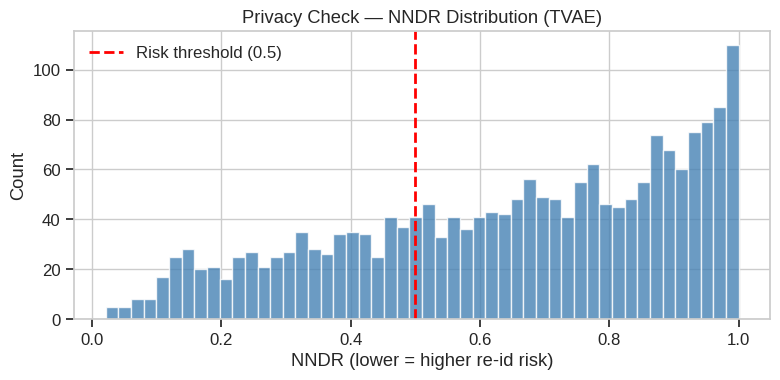

privacy_nndr.png saved ✓


{'timestamp': '2026-07-09T10:23:57.722033',
 'phase': 'phase2.5',
 'experiment': 'phase2_5_privacy_nndr',
 'seed': 42,
 'config': '{}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{"nndr_mean": 0.6464193641296773, "at_risk_frac": 0.2965}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': ''}

In [23]:

def nndr_privacy_check(synth_arr, real_arr, n_synthetic=2000, n_real=2000, n_neighbors=2):
    idx_s = np.random.choice(len(synth_arr), min(n_synthetic, len(synth_arr)), replace=False)
    idx_r = np.random.choice(len(real_arr),  min(n_real,      len(real_arr)),  replace=False)
    S = synth_arr[idx_s]; R = real_arr[idx_r]
    nn_model = NearestNeighbors(n_neighbors=n_neighbors, algorithm='auto', n_jobs=-1)
    nn_model.fit(R)
    distances, _ = nn_model.kneighbors(S)
    return distances[:, 0] / (distances[:, 1] + 1e-12)

print('=== PRIVACY CHECK (Nearest-Neighbour Distance Ratio) ===')
print('Low NNDR (<0.5) → synthetic sample is suspiciously close to a specific real sample.\n')

best_filtered_arr = filtered_generators[BEST_GENERATOR]
nndr_scores = nndr_privacy_check(best_filtered_arr, REAL_GEN_ARR)

risk_threshold = 0.5
at_risk_frac = (nndr_scores < risk_threshold).mean()

print(f'Generator: {BEST_GENERATOR}')
print(f'Samples checked: {len(nndr_scores):,}')
print(f'NNDR mean: {nndr_scores.mean():.4f}   median: {np.median(nndr_scores):.4f}')
print(f'NNDR < {risk_threshold} (at-risk): {at_risk_frac*100:.1f}%')

if at_risk_frac < 0.01:
    print('\n✅ PRIVACY: Low re-identification risk (<1% at-risk samples)')
elif at_risk_frac < 0.05:
    print('\n⚠️ PRIVACY: Moderate risk. Consider adding DP noise or increasing latent dim.')
else:
    print('\n❌ PRIVACY: High re-identification risk. Do NOT release this synthetic data.')
    print('   Mitigations: larger latent space, differential privacy, or Gaussian Copula.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nndr_scores, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(risk_threshold, color='red', linestyle='--', linewidth=2, label=f'Risk threshold ({risk_threshold})')
ax.set_xlabel('NNDR (lower = higher re-id risk)'); ax.set_ylabel('Count')
ax.set_title(f'Privacy Check — NNDR Distribution ({BEST_GENERATOR})')
ax.legend()
plt.tight_layout()
plt.savefig('privacy_nndr.png', dpi=120, bbox_inches='tight')
plt.show()
print('privacy_nndr.png saved ✓')

log_experiment('phase2_5_privacy_nndr', phase='phase2.5',
               quality_metrics={'nndr_mean': float(nndr_scores.mean()), 'at_risk_frac': float(at_risk_frac)})


## 23. Feature-Engineer Synthetic Rows (Same Modules as Section 5)

The best generator's filtered synthetic pool only has the ~80 generator features. To use
it for classifier training we need the **full** classifier feature space. Since we can't
re-run every raw-column-dependent module (some raw IEEE-CIS columns were target/frequency/
one-hot encoded away and are not part of `GENERATOR_FEATURE_COLS`), we reconstruct a
classifier-shaped row by:

1. Starting from the per-feature **real fraud training distribution** for every classifier
   column NOT in the generator set (these are held at their real-fraud empirical
   distribution — sampled with replacement from real fraud rows — since the generator was
   never asked to model them).
2. Overwriting the generator-modeled columns with the synthetic generator output.
3. Re-deriving any engineered column that is a pure function of other engineered columns
   already present (e.g. z-scores that depend on group means computed at merge time) is
   skipped here since those were computed at the population level in Section 5 — instead we
   keep the synthetic values for whichever of those columns made it into the generator set,
   and fall back to real-fraud sampling for the rest. This keeps the pipeline honest about
   what the generator actually learned vs. what is being statistically bootstrapped.


In [24]:

t0 = time.time()

def reconstruct_full_feature_rows(synth_gen_arr, real_fraud_full_df, generator_feature_cols,
                                    all_feature_cols, seed=SEED):
    '''
    Build classifier-shaped synthetic rows:
      - columns in generator_feature_cols → taken directly from the generator output
      - all other columns → bootstrap-sampled (with replacement) from real fraud rows,
        preserving the joint distribution of the non-generated columns among themselves
    '''
    n = len(synth_gen_arr)
    rng = np.random.RandomState(seed)
    donor_idx = rng.choice(len(real_fraud_full_df), size=n, replace=True)
    out_df = real_fraud_full_df.iloc[donor_idx].reset_index(drop=True).copy()

    gen_df = pd.DataFrame(synth_gen_arr, columns=generator_feature_cols)
    for col in generator_feature_cols:
        if col in out_df.columns:
            out_df[col] = gen_df[col].values
    return out_df[all_feature_cols]

print('Reconstructing full classifier-feature rows for each generator’s filtered pool …')
full_synth_pools = {}
for gen_name, filtered_arr in filtered_generators.items():
    full_synth_pools[gen_name] = reconstruct_full_feature_rows(
        filtered_arr, fraud_df_raw_full, GENERATOR_FEATURE_COLS, FEATURE_COLS)
    print(f'  {gen_name}: {full_synth_pools[gen_name].shape}')

best_synth_full_df = full_synth_pools[BEST_GENERATOR]
print(f'\nBest generator ({BEST_GENERATOR}) full-feature synthetic pool: {best_synth_full_df.shape}')

log_experiment('post_generation_feature_reconstruction', phase='phase2.5',
               config={'generators': list(full_synth_pools.keys())},
               timing_s=time.time()-t0,
               notes='generator columns taken from synthetic output; remaining classifier '
                     'columns bootstrap-sampled from real fraud to preserve joint structure')


Reconstructing full classifier-feature rows for each generator’s filtered pool …
  BetaCVAE: (43392, 414)
  CTGAN: (42649, 414)
  TVAE: (42623, 414)
  GaussianCopula: (43364, 414)
  CopulaGAN: (42704, 414)

Best generator (TVAE) full-feature synthetic pool: (42623, 414)


{'timestamp': '2026-07-09T10:23:59.346075',
 'phase': 'phase2.5',
 'experiment': 'post_generation_feature_reconstruction',
 'seed': 42,
 'config': '{"generators": ["BetaCVAE", "CTGAN", "TVAE", "GaussianCopula", "CopulaGAN"]}',
 'timing_s': 1.61,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': 'generator columns taken from synthetic output; remaining classifier columns bootstrap-sampled from real fraud to preserve joint structure'}

## 24. Adaptive Augmentation Ratio Search

Instead of a fixed 30% (or even a fixed 30/50/70% ablation), the augmentation ratio is
now searched automatically over `{10, 20, 30, 40, 60, 80, 100}%` of the real fraud count,
using validation F1 as the selection criterion. Most datasets peak around 20–40%, but we
verify rather than assume.


ADAPTIVE AUGMENTATION RATIO SEARCH — generator: TVAE
  ratio=10%  +1,446 synthetic  F1=0.6854  ROC-AUC=0.9522  Recall=0.6087
  ratio=20%  +2,892 synthetic  F1=0.6859  ROC-AUC=0.9521  Recall=0.6032
  ratio=30%  +4,339 synthetic  F1=0.6865  ROC-AUC=0.9517  Recall=0.6229
  ratio=40%  +5,785 synthetic  F1=0.6810  ROC-AUC=0.9511  Recall=0.5871
  ratio=60%  +8,678 synthetic  F1=0.6805  ROC-AUC=0.9513  Recall=0.6252
  ratio=80%  +11,571 synthetic  F1=0.6807  ROC-AUC=0.9512  Recall=0.6045
  ratio=100%  +14,464 synthetic  F1=0.6874  ROC-AUC=0.9519  Recall=0.6135

🏆 Best augmentation ratio: 100%  (val F1=0.6874)


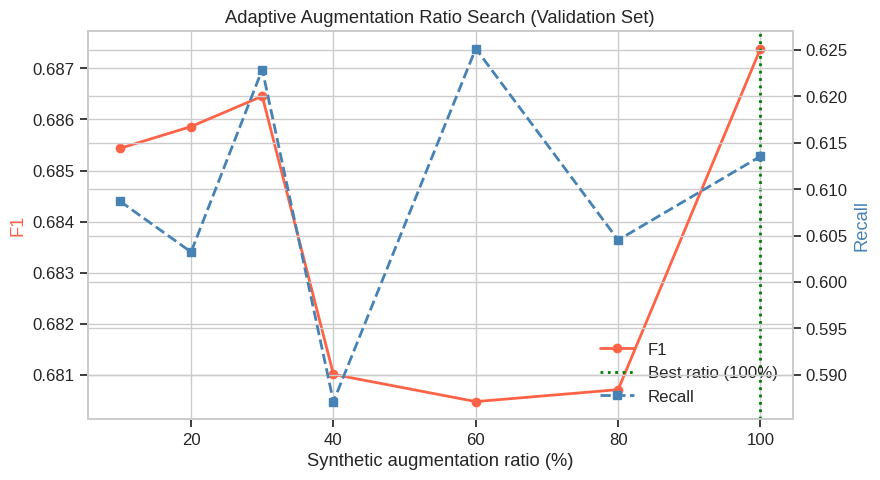

phase2_5_ratio_search.png saved ✓


{'timestamp': '2026-07-09T10:26:01.676877',
 'phase': 'phase2.5',
 'experiment': 'adaptive_augmentation_ratio_search',
 'seed': 42,
 'config': '{"ratio_grid": [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0], "generator": "TVAE"}',
 'timing_s': 122.31,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{"ratio": [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0], "n_synthetic_added": [1446, 2892, 4339, 5785, 8678, 11571, 14464], "F1": [0.6854340714294836, 0.6858609934576683, 0.6864557407067688, 0.6810102895034393, 0.6804775275938023, 0.6807119501072896, 0.6873870613070248], "ROC_AUC": [0.9522164046264194, 0.9521424493124487, 0.9516670163639459, 0.9510704227424995, 0.9513422601740209, 0.951184622804313, 0.9519256835418246], "Recall": [0.6087096774193549, 0.603225806451613, 0.6229032258064516, 0.5870967741935483, 0.6251612903225806, 0.604516129032258, 0.6135483870967742], "threshold": [0.8598628640174866, 0.856547474861145, 0.8281103372573853, 0.8543940186500549, 0.7919679880142212, 0.796998143196106, 0

In [25]:

t0 = time.time()

def build_augmented(ratio, synth_full_df):
    '''Add `ratio` fraction of synthetic fraud (relative to real fraud count in train).'''
    n_add = int(n_real_fraud * ratio)
    n_add = min(n_add, len(synth_full_df))
    synth_add = synth_full_df.iloc[:n_add][FEATURE_COLS].values
    X_aug = np.vstack([X_train_qt, qt.transform(synth_add)])
    y_aug = np.concatenate([y_train, np.ones(n_add, dtype=int)])
    return X_aug, y_aug, n_add

def quick_train_eval(X_tr, y_tr, X_val, y_val):
    '''Fast classifier used purely for ratio search (not the final model).'''
    sp = max(1, (y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
    clf = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.08, max_depth=6,
        min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=sp, device='cuda' if DEVICE == 'cuda' else 'cpu',
        tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0,
        eval_metric='logloss', early_stopping_rounds=25)
    clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    prob = clf.predict_proba(X_val)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_val, prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1s[:-1])
    return {
        'F1': f1s[best_idx], 'threshold': thresholds[best_idx],
        'ROC_AUC': roc_auc_score(y_val, prob),
        'Recall': recall_score(y_val, (prob >= thresholds[best_idx]).astype(int)),
        'clf': clf,
    }

RATIO_GRID = [0.10, 0.20, 0.30, 0.40, 0.60, 0.80, 1.00]
ratio_search_results = []

print('='*70)
print(f'ADAPTIVE AUGMENTATION RATIO SEARCH — generator: {BEST_GENERATOR}')
print('='*70)

for ratio in RATIO_GRID:
    X_aug, y_aug, n_add = build_augmented(ratio, best_synth_full_df)
    res = quick_train_eval(X_aug, y_aug, X_val_qt, y_val)
    ratio_search_results.append({
        'ratio': ratio, 'n_synthetic_added': n_add,
        'F1': res['F1'], 'ROC_AUC': res['ROC_AUC'], 'Recall': res['Recall'],
        'threshold': res['threshold'],
    })
    print(f'  ratio={ratio:.0%}  +{n_add:,} synthetic  F1={res["F1"]:.4f}  '
          f'ROC-AUC={res["ROC_AUC"]:.4f}  Recall={res["Recall"]:.4f}')

ratio_search_df = pd.DataFrame(ratio_search_results)
best_ratio_row = ratio_search_df.loc[ratio_search_df['F1'].idxmax()]
BEST_RATIO = best_ratio_row['ratio']
print(f'\n🏆 Best augmentation ratio: {BEST_RATIO:.0%}  (val F1={best_ratio_row["F1"]:.4f})')

fig, ax = plt.subplots(figsize=(9, 5))
ax2 = ax.twinx()
ax.plot(ratio_search_df['ratio']*100, ratio_search_df['F1'], 'o-', color='tomato', label='F1', lw=2)
ax2.plot(ratio_search_df['ratio']*100, ratio_search_df['Recall'], 's--', color='steelblue', label='Recall', lw=2)
ax.axvline(BEST_RATIO*100, color='green', linestyle=':', lw=2, label=f'Best ratio ({BEST_RATIO:.0%})')
ax.set_xlabel('Synthetic augmentation ratio (%)'); ax.set_ylabel('F1', color='tomato')
ax2.set_ylabel('Recall', color='steelblue')
ax.set_title('Adaptive Augmentation Ratio Search (Validation Set)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.savefig('phase2_5_ratio_search.png', dpi=130, bbox_inches='tight')
plt.show()
print('phase2_5_ratio_search.png saved ✓')

ratio_search_df.to_csv('phase2_5_ratio_search_results.csv', index=False)
log_experiment('adaptive_augmentation_ratio_search', phase='phase2.5',
               config={'ratio_grid': RATIO_GRID, 'generator': BEST_GENERATOR},
               timing_s=time.time()-t0,
               val_metrics=ratio_search_df.to_dict(orient='list'),
               notes=f'best ratio = {BEST_RATIO:.0%}')


## 25. Final Augmented Training Set & Held-Out Test Evaluation

In [26]:

X_aug_final, y_aug_final, n_add_final = build_augmented(BEST_RATIO, best_synth_full_df)
print(f'Final augmented train: {X_aug_final.shape}  fraud: {y_aug_final.mean()*100:.2f}%  '
      f'(+{n_add_final:,} synthetic from {BEST_GENERATOR} @ {BEST_RATIO:.0%})')

t0 = time.time()
sp_final = max(1, (y_aug_final == 0).sum() / max((y_aug_final == 1).sum(), 1))
phase2_model = xgb.XGBClassifier(
    n_estimators=800, learning_rate=0.04, max_depth=7,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=sp_final, reg_alpha=0.01, reg_lambda=0.1,
    device='cuda' if DEVICE=='cuda' else 'cpu',
    tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='logloss', early_stopping_rounds=40)
phase2_model.fit(X_aug_final, y_aug_final, eval_set=[(X_val_qt, y_val)], verbose=False)

val_prob = phase2_model.predict_proba(X_val_qt)[:, 1]
final_thresh, _ = find_optimal_threshold(y_val, val_prob)
test_prob = phase2_model.predict_proba(X_test_qt)[:, 1]
test_pred = (test_prob >= final_thresh).astype(int)

test_roc  = roc_auc_score(y_test, test_prob)
test_ap   = average_precision_score(y_test, test_prob)
test_f1   = f1_score(y_test, test_pred)
test_rec  = recall_score(y_test, test_pred)
test_prec = precision_score(y_test, test_pred, zero_division=0)

print(f'\n{"="*60}')
print('PHASE 2 TEST SET RESULTS (informational — Phase 3 does the real model selection)')
print(f'{"="*60}')
print(f'Threshold used:        {final_thresh:.4f}')
print(f'ROC-AUC:              {test_roc:.4f}')
print(f'Average Precision:    {test_ap:.4f}')
print(f'F1 Score:             {test_f1:.4f}')
print(f'Recall (Fraud):       {test_rec:.4f}')
print(f'Precision:            {test_prec:.4f}')
print(classification_report(y_test, test_pred, target_names=['Legitimate', 'Fraud']))

best_phase1_f1     = baseline_df['F1'].max()
best_phase1_auc    = baseline_df['ROC_AUC'].max()
best_phase1_recall = baseline_df['Recall_Fraud'].max()

print(f'\n{"="*60}')
print('PHASE 1 vs PHASE 2 IMPROVEMENT')
print(f'{"="*60}')
print(f'F1 Score        | {best_phase1_f1:.4f} → {test_f1:.4f}  ({test_f1 - best_phase1_f1:+.4f})')
print(f'ROC-AUC         | {best_phase1_auc:.4f} → {test_roc:.4f}  ({test_roc - best_phase1_auc:+.4f})')
print(f'Recall (Fraud)  | {best_phase1_recall:.4f} → {test_rec:.4f}  ({test_rec - best_phase1_recall:+.4f})')

log_experiment('phase2_final_holdout_eval', phase='phase2',
               config={'generator': BEST_GENERATOR, 'ratio': BEST_RATIO},
               timing_s=time.time()-t0,
               val_metrics={'F1': float(f1_score(y_val, (val_prob>=final_thresh).astype(int))),
                            'ROC_AUC': float(roc_auc_score(y_val, val_prob))},
               test_metrics={'F1': test_f1, 'ROC_AUC': test_roc, 'Recall': test_rec, 'Precision': test_prec},
               notes='informational only — Phase 3 notebook re-selects the final classifier')


Final augmented train: (427842, 414)  fraud: 6.76%  (+14,464 synthetic from TVAE @ 100%)

PHASE 2 TEST SET RESULTS (informational — Phase 3 does the real model selection)
Threshold used:        0.7385
ROC-AUC:              0.9639
Average Precision:    0.7803
F1 Score:             0.7265
Recall (Fraud):       0.6596
Precision:            0.8085
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     85482
       Fraud       0.81      0.66      0.73      3099

    accuracy                           0.98     88581
   macro avg       0.90      0.83      0.86     88581
weighted avg       0.98      0.98      0.98     88581


PHASE 1 vs PHASE 2 IMPROVEMENT
F1 Score        | 0.7087 → 0.7265  (+0.0178)
ROC-AUC         | 0.9566 → 0.9639  (+0.0073)
Recall (Fraud)  | 0.6342 → 0.6596  (+0.0254)


{'timestamp': '2026-07-09T10:26:34.935231',
 'phase': 'phase2',
 'experiment': 'phase2_final_holdout_eval',
 'seed': 42,
 'config': '{"generator": "TVAE", "ratio": 1.0}',
 'timing_s': 31.74,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{"F1": 0.7277916518016411, "ROC_AUC": 0.9597647090789087}',
 'test_metrics': '{"F1": 0.7264972454238493, "ROC_AUC": 0.9639226576907145, "Recall": 0.659567602452404, "Precision": 0.8085443037974683}',
 'notes': 'informational only — Phase 3 notebook re-selects the final classifier'}

## 26. Save All Outputs (for Phase 3 / 3.5 / 4)

In [27]:

t0 = time.time()

# ── VAE model + scalers ────────────────────────────────────────────────────────
torch.save({
    'model_state_dict': best_model.state_dict(),
    'input_dim': INPUT_DIM, 'hidden_dims': HIDDEN_DIMS,
    'latent_dim': LATENT_DIM, 'beta': BETA,
    'cont_idx': CONT_IDX, 'bin_idx': BIN_IDX,
    'generator_feature_cols': GENERATOR_FEATURE_COLS,
    'best_loss': best_loss, 'hp_search': search_df.to_dict(),
    'vae_converged': VAE_CONVERGED,
}, 'vae_model.pt')
print('vae_model.pt saved ✓')

joblib.dump(qt, 'fraud_quantile_transformer.pkl')
joblib.dump(qt_gen, 'fraud_quantile_transformer_generator.pkl')
print('Quantile transformers saved ✓')

# ── Synthetic data (per generator + best pool) ────────────────────────────────
synth_vae_df.to_csv('synthetic_fraud_beta_cvae.csv', index=False)
if ctgan_synth_df is not None:     ctgan_synth_df.to_csv('synthetic_fraud_ctgan.csv', index=False)
if tvae_synth_df is not None:      tvae_synth_df.to_csv('synthetic_fraud_tvae.csv', index=False)
if copula_synth_df is not None:    copula_synth_df.to_csv('synthetic_fraud_gaussian_copula.csv', index=False)
if copulagan_synth_df is not None: copulagan_synth_df.to_csv('synthetic_fraud_copulagan.csv', index=False)
best_synth_full_df.to_csv('synthetic_fraud_best_generator_full_features.csv', index=False)
print('Synthetic CSVs saved ✓')

# ── Augmented splits (train uses BEST_RATIO of BEST_GENERATOR; val/test untouched) ──
aug_df = pd.DataFrame(np.column_stack([X_aug_final, y_aug_final]), columns=FEATURE_COLS + ['isFraud'])
aug_df.sample(frac=1, random_state=SEED).to_csv('augmented_train_qt.csv', index=False)
pd.DataFrame(np.column_stack([X_val_qt,  y_val]),  columns=FEATURE_COLS + ['isFraud']).to_csv('val_qt.csv', index=False)
pd.DataFrame(np.column_stack([X_test_qt, y_test]), columns=FEATURE_COLS + ['isFraud']).to_csv('test_qt.csv', index=False)
print('Split CSVs saved ✓')

# ── Results & metadata ─────────────────────────────────────────────────────────
baseline_df.to_csv('phase1_baseline_results.csv')
cv_df.to_csv('phase1_cv_results.csv')
search_df.to_csv('hp_search_results.csv', index=False)
leaderboard.to_csv('phase2_5_generator_leaderboard.csv')
filter_report_df.to_csv('phase2_5_filter_report.csv')
ratio_search_df.to_csv('phase2_5_ratio_search_results.csv', index=False)

pipeline_meta = {
    'best_generator': BEST_GENERATOR,
    'best_augmentation_ratio': BEST_RATIO,
    'n_synthetic_added': n_add_final,
    'generator_feature_cols': GENERATOR_FEATURE_COLS,
    'classifier_feature_cols': FEATURE_COLS,
    'vae_converged': VAE_CONVERGED,
    'phase2_test_f1': test_f1,
    'phase2_test_roc_auc': test_roc,
    'phase2_test_recall': test_rec,
}
joblib.dump(pipeline_meta, 'phase2_pipeline_meta.pkl')
print('phase2_pipeline_meta.pkl saved ✓')

log_experiment('save_all_outputs', phase='phase2.5', timing_s=time.time()-t0,
               notes='all Phase 1/2/2.5 artifacts persisted for Phase 3 notebook')

print()
print('='*70)
print('🎉 Phase 1 + Phase 2 + Phase 2.5 pipeline complete!')
print('='*70)
print('Key outputs for the next notebook (Phase 3 / 3.5):')
print('  augmented_train_qt.csv          → train split + best generator @ best ratio')
print('  val_qt.csv / test_qt.csv        → untouched validation / held-out test splits')
print('  phase1_baseline_results.csv     → Phase 1 reference metrics')
print('  phase2_pipeline_meta.pkl        → best generator/ratio + feature column lists')
print('  phase2_5_generator_leaderboard.csv → full Phase 2.5 validation results (all 5 generators)')
print('  experiment_log.csv              → every experiment run in this notebook, timestamped')
print('='*70)


vae_model.pt saved ✓
Quantile transformers saved ✓
Synthetic CSVs saved ✓
Split CSVs saved ✓
phase2_pipeline_meta.pkl saved ✓

🎉 Phase 1 + Phase 2 + Phase 2.5 pipeline complete!
Key outputs for the next notebook (Phase 3 / 3.5):
  augmented_train_qt.csv          → train split + best generator @ best ratio
  val_qt.csv / test_qt.csv        → untouched validation / held-out test splits
  phase1_baseline_results.csv     → Phase 1 reference metrics
  phase2_pipeline_meta.pkl        → best generator/ratio + feature column lists
  phase2_5_generator_leaderboard.csv → full Phase 2.5 validation results (all 5 generators)
  experiment_log.csv              → every experiment run in this notebook, timestamped
